# **Block 0 : Setup**


**For graph distances, the Som, and the evaluation metricsThis block defines everything the later blocks use and nothing else. It has four parts.First the four graph distances (GED, Spectral, Weisfeiler-Lehman, ShortestPath),each exposing distance matrix(graphs) -> n x n symmetric matrix.Second the median SOM: prototypes are graphs from the dataset, chosen at each epoch as theneighbourhood weighted medoid, with a shrinking Gaussian neighbourhood. Third the evaluation metrics,grouped by what they measure (the distance itself, the geometry of a dataset, the map, or the partition).Fourth a set of helpers added for this work: exhaustive graph generation through nauty, covariate matching, permutation nulls, and a disk cache for distance matrices, which is what makes the notebook**

In [1]:
!apt-get install -y nauty -qq

import os, random, hashlib, shutil, subprocess, time, pathlib, warnings
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from fractions import Fraction
from numpy.linalg import lstsq
from scipy.stats import spearmanr
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, silhouette_score, roc_auc_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)


NM = lambda a, b: a.get("label") == b.get("label")

DUST_ATOL = 1e-7

def _kernel_to_distance(K):
    d = np.sqrt(np.clip(np.diag(K), 1e-12, None))
    Kn = np.clip(K / np.outer(d, d), -1.0, 1.0)
    D = np.sqrt(np.clip(2.0 - 2.0 * Kn, 0.0, None))
    np.fill_diagonal(D, 0.0)
    return D

class GEDDistance:
    name = "GED"
    _cache = {}

    def __init__(self, timeout=2.0):
        self.timeout = timeout

    @staticmethod
    def _sig(g):
        nodes = tuple(sorted(str(g.nodes[v].get("label", "")) for v in g.nodes()))
        edges = tuple(sorted(tuple(sorted(e)) for e in g.edges()))
        return (nodes, edges)

    def distance_matrix(self, graphs):
        n = len(graphs)
        D = np.zeros((n, n))
        sigs = [self._sig(g) for g in graphs]
        for i in range(n):
            for j in range(i + 1, n):
                pair = (sigs[i], sigs[j]) if sigs[i] <= sigs[j] else (sigs[j], sigs[i])
                key = (self.timeout,) + pair
                if key not in self._cache:
                    self._cache[key] = float(nx.graph_edit_distance(
                        graphs[i], graphs[j], node_match=NM, timeout=self.timeout))
                D[i, j] = D[j, i] = self._cache[key]
        return D

class SpectralDistance:
    name = "Spectral"

    def _spectrum(self, g):
        if g.number_of_nodes() == 0:
            return np.array([0.0])
        L = nx.laplacian_matrix(g).toarray().astype(float)
        return np.sort(np.linalg.eigvalsh(L))

    def distance_matrix(self, graphs):
        specs = [self._spectrum(g) for g in graphs]
        m = max(len(s) for s in specs)
        specs = [np.concatenate([np.zeros(m - len(s)), s]) for s in specs]
        n = len(graphs)
        D = np.zeros((n, n))
        for i in range(n):
            for j in range(i + 1, n):
                D[i, j] = D[j, i] = float(np.linalg.norm(specs[i] - specs[j]))
        return D

class WLDistance:
    name = "WL"

    def __init__(self, h=3):
        self.h = h

    def distance_matrix(self, graphs):
        labels = [{v: str(g.nodes[v].get("label", "1")) for v in g.nodes()} for g in graphs]
        feats = [Counter() for _ in graphs]
        compress = {}

        def code(s):
            if s not in compress:
                compress[s] = len(compress)
            return compress[s]

        for gi, g in enumerate(graphs):
            for v in g.nodes():
                feats[gi][code("0_" + labels[gi][v])] += 1
        for it in range(1, self.h + 1):
            new = []
            for gi, g in enumerate(graphs):
                nl = {}
                for v in g.nodes():
                    neigh = sorted(labels[gi][u] for u in g.neighbors(v))
                    sig = labels[gi][v] + "|" + ",".join(neigh)
                    hsh = hashlib.md5(sig.encode()).hexdigest()[:12]
                    nl[v] = hsh
                    feats[gi][code(f"{it}_{hsh}")] += 1
                new.append(nl)
            labels = new
        F = np.zeros((len(graphs), len(compress)))
        for gi, c in enumerate(feats):
            for k, v in c.items():
                F[gi, k] = v
        return _kernel_to_distance(F @ F.T)

class SPDistance:
    name = "SP"

    def _hist(self, g):
        c = Counter()
        for src, dmap in nx.all_pairs_shortest_path_length(g):
            for dst, dist in dmap.items():
                if src < dst:
                    c[dist] += 1
        return c

    def distance_matrix(self, graphs):
        hists = [self._hist(g) for g in graphs]
        maxd = max([max(h.keys()) for h in hists if h] + [0])
        F = np.zeros((len(graphs), maxd + 1))
        for gi, h in enumerate(hists):
            for length, cnt in h.items():
                F[gi, length] = cnt
        return _kernel_to_distance(F @ F.T)

def all_distances():
    return [GEDDistance(timeout=1.0), SpectralDistance(), WLDistance(h=3), SPDistance()]

def _lab(g, label="A"):
    for v in g.nodes():
        g.nodes[v]["label"] = label
    return g

def _wl_hash(g, iterations=4):
    has_labels = any("label" in g.nodes[v] for v in g.nodes())
    return nx.weisfeiler_lehman_graph_hash(
        g, iterations=iterations, node_attr="label" if has_labels else None)

_GENG = shutil.which("geng") or shutil.which("nauty-geng")

NAUTY_AVAILABLE = _GENG is not None

_GENG_CACHE = {}

def nauty_geng():
    return shutil.which("geng") or shutil.which("nauty-geng")

def geng_all(n, min_edges=None, max_edges=None, connected=True):
    exe = nauty_geng()
    if exe is None:
        raise RuntimeError("geng not found; install nauty (apt-get install -y nauty)")
    key = (n, min_edges, max_edges, connected)
    if key not in _GENG_CACHE:
        args = [exe, str(n)]
        if connected:
            args.append("-c")
        if min_edges is not None or max_edges is not None:
            lo = 0 if min_edges is None else min_edges
            hi = n * (n - 1) // 2 if max_edges is None else max_edges
            args.append(f"{lo}:{hi}")
        out = subprocess.run(args, capture_output=True, text=True, check=True).stdout
        _GENG_CACHE[key] = [nx.from_graph6_bytes(l.encode()) for l in out.split() if l]
    return [g.copy() for g in _GENG_CACHE[key]]

_NAUTY_WARNED = [False]

def _nauty_or_warn():
    ok = nauty_geng() is not None
    if not ok and not _NAUTY_WARNED[0]:
        print("nauty not found")
        _NAUTY_WARNED[0] = True
    return ok

def kmedoids(D, k, seed, max_iter=100):
    rng = np.random.default_rng(seed)
    n = D.shape[0]
    centres = rng.choice(n, size=k, replace=False)
    labels = np.argmin(D[:, centres], axis=1)
    for _ in range(max_iter):
        new_centres = centres.copy()
        for c in range(k):
            members = np.where(labels == c)[0]
            if len(members):
                sub = D[np.ix_(members, members)]
                new_centres[c] = members[np.argmin(sub.sum(axis=1))]
        new_labels = np.argmin(D[:, new_centres], axis=1)
        if np.array_equal(new_labels, labels) and np.array_equal(new_centres, centres):
            break
        centres, labels = new_centres, new_labels
    return labels

def separation_auc(D, labels):
    labels = np.asarray(labels)
    iu = np.triu_indices(len(labels), k=1)
    y_diff = (labels[iu[0]] != labels[iu[1]]).astype(int)
    if len(np.unique(y_diff)) < 2:
        return 0.5
    return float(roc_auc_score(y_diff, D[iu]))

def safe_silhouette(D, labels):
    labels = np.asarray(labels)
    if len(np.unique(labels)) < 2 or np.allclose(D, 0):
        return np.nan
    try:
        return float(silhouette_score(D, labels, metric="precomputed"))
    except Exception:
        return np.nan

def two_closest_neurons(D, prototypes):
    dist_to_neuron = D[:, prototypes]
    order = np.argsort(dist_to_neuron, axis=1)
    return order[:, 0], order[:, 1]

def topographic_error(D, prototypes, coords):
    b1, b2 = two_closest_neurons(D, prototypes)
    grid_gap = np.sqrt(((coords[b1] - coords[b2]) ** 2).sum(axis=1))
    return float(np.mean(grid_gap > 1.0001))

def umatrix(D, prototypes, coords, rows, cols):
    K = len(prototypes)
    U = np.full(rows * cols, np.nan)
    for j in range(K):
        neighbours = [k for k in range(K)
                      if 0 < np.sqrt(((coords[j] - coords[k]) ** 2).sum()) <= 1.0001]
        if neighbours:
            U[j] = np.mean([D[prototypes[j], prototypes[k]] for k in neighbours])
    return U.reshape(rows, cols)

def quantization_error(D, prototypes):
    return float(np.min(D[:, prototypes], axis=1).mean())

def _grid_neighbours_4(coords):
    K = len(coords)
    adj = {j: [] for j in range(K)}
    for a in range(K):
        for b in range(a + 1, K):
            if abs(np.sqrt(((coords[a] - coords[b]) ** 2).sum()) - 1.0) < 1e-6:
                adj[a].append(b); adj[b].append(a)
    return adj

def _connected_pieces(cells, adj):
    cells = set(cells); seen = set(); pieces = 0
    for start in cells:
        if start in seen:
            continue
        pieces += 1; stack = [start]
        while stack:
            v = stack.pop()
            if v in seen:
                continue
            seen.add(v)
            for u in adj[v]:
                if u in cells and u not in seen:
                    stack.append(u)
    return pieces

def merge_prototypes_to_k(D, prototypes, k):
    if len(prototypes) <= k:
        return np.argmin(D[:, prototypes], axis=1)
    Dsub = D[np.ix_(prototypes, prototypes)]
    grp = AgglomerativeClustering(n_clusters=k, metric="precomputed",
                                  linkage="average").fit_predict(Dsub)
    return grp[np.argmin(D[:, prototypes], axis=1)]

def map_quality(D, labels, som, k):
    labels = np.asarray(labels)
    protos = som.prototypes_
    adj = _grid_neighbours_4(som.coords)
    bmu = np.argmin(D[:, protos], axis=1)
    ari_fine = adjusted_rand_score(labels, bmu)
    ari_merged = adjusted_rand_score(labels, merge_prototypes_to_k(D, protos, k))

    majority = {}
    for j in range(len(protos)):
        members = np.where(bmu == j)[0]
        if len(members):
            majority[j] = Counter(labels[members]).most_common(1)[0][0]

    piece_list, conc_list = [], []
    for c in np.unique(labels):
        territory = [j for j, mc in majority.items() if mc == c]
        if not territory:
            piece_list.append(0); conc_list.append(0.0); continue
        piece_list.append(_connected_pieces(territory, adj))
        seen, blobs, tset = set(), [], set(territory)
        for start in territory:
            if start in seen:
                continue
            stack = [start]; blob = []
            while stack:
                v = stack.pop()
                if v in seen:
                    continue
                seen.add(v); blob.append(v)
                for u in adj[v]:
                    if u in tset and u not in seen:
                        stack.append(u)
            blobs.append(blob)
        cg = np.where(labels == c)[0]
        best = max(blobs, key=lambda bl: sum(bmu[g] in set(bl) for g in cg))
        conc_list.append(float(np.mean([bmu[g] in set(best) for g in cg])))

    return {"ari_fine": ari_fine, "ari_merged": ari_merged,
            "pieces": float(np.mean(piece_list)),
            "concentration": float(np.mean(conc_list))}

def _clean_D(D, atol=DUST_ATOL):
    D = np.asarray(D, float).copy()
    D = 0.5 * (D + D.T)
    D[D < atol] = 0.0
    np.fill_diagonal(D, 0.0)
    return D

def is_k_colorable(g, k):
    nodes = list(g.nodes()); color = {}
    def bt(i):
        if i == len(nodes):
            return True
        v = nodes[i]
        for c in range(k):
            if all(color.get(u) != c for u in g.neighbors(v)):
                color[v] = c
                if bt(i + 1):
                    return True
                del color[v]
        return False
    return bt(0)

def chromatic_number(g):
    if g.number_of_edges() == 0:
        return 1
    for k in range(1, g.number_of_nodes() + 1):
        if is_k_colorable(g, k):
            return k
    return g.number_of_nodes()

def _knee_index(x, y_decreasing):
    x = np.asarray(x, float); y = np.asarray(y_decreasing, float)
    if len(x) < 3:
        return 0
    stop = int(np.argmin(y)) + 1
    xt, yt = x[:stop], y[:stop]
    if len(xt) < 3:
        return int(np.argmin(y))
    xn = (xt - xt.min()) / (xt.max() - xt.min() + 1e-12)
    yn = (yt - yt.min()) / (yt.max() - yt.min() + 1e-12)
    chord = yn[0] + (yn[-1] - yn[0]) * xn
    return int(np.argmax(chord - yn))

def merge_to_best_silhouette(D, protos, k_min=2, k_max=None):
    K = len(protos)
    bmu = np.argmin(D[:, protos], axis=1)
    Dsub = D[np.ix_(protos, protos)]
    Dsub = 0.5 * (Dsub + Dsub.T)
    np.fill_diagonal(Dsub, 0.0)
    if K < 2 or Dsub.max() == 0.0:
        return {"pred": np.zeros(len(bmu), int), "sil": np.nan,
                "n_clusters": 1, "curve": [], "degenerate": True}

    Z = linkage(squareform(Dsub, checks=False), method="average")
    k_max = min(k_max or K, K)
    best, curve = None, []
    for k in range(k_min, k_max + 1):
        pred = (fcluster(Z, k, criterion="maxclust") - 1)[bmu]
        if len(np.unique(pred)) < 2:
            continue
        s = safe_silhouette(D, pred)
        curve.append((k, s))
        if not np.isnan(s) and (best is None or s > best[1]):
            best = (k, s, pred)

    if best is None:
        return {"pred": np.zeros(len(bmu), int), "sil": np.nan,
                "n_clusters": 1, "curve": curve, "degenerate": True}
    k_best, s_best, pred = best
    return {"pred": pred, "sil": s_best, "n_clusters": k_best,
            "curve": curve, "degenerate": False}

class MedianSOM:
    def __init__(self, grid_shape=(3, 3), n_epochs=40, seed=0):
        self.rows, self.cols = grid_shape
        self.K = self.rows * self.cols
        self.n_epochs = n_epochs
        self.seed = seed
        self.coords = np.array([(r, c) for r in range(self.rows)
                                for c in range(self.cols)], float)
        diff = self.coords[:, None, :] - self.coords[None, :, :]
        self.grid_dist = np.sqrt((diff ** 2).sum(-1))

    def fit(self, D):
        D = np.asarray(D, float)
        n = D.shape[0]
        rng = np.random.default_rng(self.seed)
        K = min(self.K, n)
        proto = rng.choice(n, size=K, replace=False)
        gd = self.grid_dist[:K, :K]
        sigma0 = max(self.rows, self.cols) / 2.0 + 1e-6

        for epoch in range(self.n_epochs):
            frac = epoch / max(self.n_epochs - 1, 1)
            sigma = sigma0 * (0.3 / sigma0) ** frac
            bmu = np.argmin(D[:, proto], axis=1)
            H = np.exp(-(gd ** 2) / (2 * sigma ** 2))
            proto = np.argmin(H[:, bmu] @ D, axis=1)

            # revive duplicates at the worst quantised graphs
            err = D[np.arange(n), proto[np.argmin(D[:, proto], axis=1)]]
            order = np.argsort(-err)
            seen, ptr = set(), 0
            for k in range(K):
                if proto[k] in seen:
                    while ptr < n and order[ptr] in proto:
                        ptr += 1
                    if ptr < n:
                        proto[k] = order[ptr]
                        ptr += 1
                seen.add(proto[k])

        self.prototypes_ = proto
        self.labels_ = np.argmin(D[:, proto], axis=1)
        self.coords_used_ = self.coords[:K]
        return self.labels_


CACHE = pathlib.Path("dcache"); CACHE.mkdir(exist_ok=True)
_T0 = {}

def prog(tag, i, n, extra=""):
    if i <= 1:
        _T0[tag] = time.time()
    el = time.time() - _T0.get(tag, time.time())
    eta = el / max(i, 1) * (n - i)
    bar = "#" * int(24 * i / n) + "." * (24 - int(24 * i / n))
    print(f"\r{tag:7s} [{bar}] {i:5d}/{n} {el:5.0f}s +{eta:5.0f}s {extra:34s}", end="", flush=True)
    if i >= n:
        print()

def _gkey(graphs, name):
    h = hashlib.md5()
    for g in graphs:
        h.update(nx.weisfeiler_lehman_graph_hash(g, iterations=3).encode())
        h.update(str(sorted(g.nodes(data="label"))).encode())
    return f"{name}_{len(graphs)}_{h.hexdigest()[:16]}"

def cached_D(graphs, dist):
    fp = CACHE / (_gkey(graphs, dist.name) + ".npy")
    if fp.exists():
        return np.load(fp)
    t = time.time()
    D = _clean_D(dist.distance_matrix(graphs))
    np.save(fp, D)
    print(f"\n  computed {dist.name:9s} n={len(graphs):3d} {time.time()-t:6.1f}s")
    return D

GED_TIMEOUT = 0.15   
GED_SEEDS = 1        

def all_distances():
    return [GEDDistance(timeout=GED_TIMEOUT), SpectralDistance(),
            WLDistance(h=3), SPDistance()]

def dists_for(seed):
    ds = [SpectralDistance(), WLDistance(h=3), SPDistance()]
    return ([GEDDistance(timeout=GED_TIMEOUT)] + ds) if seed < GED_SEEDS else ds



def _lcc_diam(g):
    c = max(nx.connected_components(g), key=len)
    return nx.diameter(g.subgraph(c)) if len(c) > 1 else 0

COVS = {"n_edges": lambda g: g.number_of_edges(),
        "n_comp":  lambda g: nx.number_connected_components(g),
        "max_deg": lambda g: max([d for _, d in g.degree()] or [0]),
        "min_deg": lambda g: min([d for _, d in g.degree()] or [0]),
        "n_tri":   lambda g: sum(nx.triangles(g).values()) // 3,
        "clust":   lambda g: nx.average_clustering(g),
        "diam":    _lcc_diam,
        "deg_var": lambda g: float(np.var([d for _, d in g.degree()] or [0])),
        "n_B":     lambda g: sum(g.nodes[v].get("label") == "B" for v in g.nodes())}

def cov_values(graphs, name):
    return np.array([COVS[name](g) for g in graphs], float)

def cov_baseline(graphs, y, exclude=()):
    best = (0.5, "-")
    for k in COVS:
        if k in exclude:
            continue
        v = cov_values(graphs, k)
        if v.std() == 0:
            continue
        a = separation_auc(np.abs(v[:, None] - v[None, :]), y)
        if a > best[0]:
            best = (a, k)
    return best

def perm_null_auc(D, y, n_perm=300, seed=0):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = [separation_auc(D, rng.permutation(y)) for _ in range(n_perm)]
    return float(np.mean(n)), float(np.quantile(n, 0.95))


def match_on(pool_by_class, per_class, keys, rng):
    b = {c: {} for c in pool_by_class}
    for c, gs in pool_by_class.items():
        for g in gs:
            b[c].setdefault(tuple(COVS[k](g) for k in keys), []).append(g)
    shared = set(b[list(pool_by_class)[0]])
    for c in pool_by_class:
        shared &= set(b[c])
    if not shared:
        return None
    cap = {k: min(len(b[c][k]) for c in pool_by_class) for k in shared}
    tot = sum(cap.values())
    per_class = min(per_class, tot)
    out = {c: [] for c in pool_by_class}
    left = per_class
    for k in sorted(shared, key=lambda k: -cap[k]):
        if left <= 0:
            break
        take = min(cap[k], max(1, int(round(per_class * cap[k] / tot))), left)
        for c in pool_by_class:
            p = b[c][k][:]; rng.shuffle(p); out[c].extend(p[:take])
        left -= take
    return out if min(len(v) for v in out.values()) > 0 else None

def emit(pool_by_class, per_class, rng):
    gs, ys = [], []
    for ci, c in enumerate(sorted(pool_by_class)):
        q = pool_by_class[c][:]; rng.shuffle(q)
        for g in q[:per_class]:
            gs.append(_lab(nx.convert_node_labels_to_integers(g.copy()))); ys.append(ci)
    return gs, np.asarray(ys)


def mds_embed(D):
    D = np.asarray(D, float); n = len(D)
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J
    B = 0.5 * (B + B.T)
    w, V = np.linalg.eigh(B)
    o = np.argsort(w)[::-1]; w, V = w[o], V[:, o]
    k = max(int((w > 1e-9).sum()), 1)
    pos = w[w > 0]
    return (V[:, :k] * np.sqrt(np.maximum(w[:k], 0)), w,
            dict(
                var_top2=float(pos[:2].sum() / (pos.sum() + 1e-12)),
                neg_mass=float(np.abs(w[w < 0]).sum() / (np.abs(w).sum() + 1e-12)),
                n_dims=k))

def geometry(D, y):
    X, w, info = mds_embed(D)
    x = X[:, 0]; cls = np.unique(y)
    mu = np.array([x[y == c].mean() for c in cls])
    sd = np.sqrt(np.mean([x[y == c].var(ddof=1) for c in cls]))
    iu = np.triu_indices(len(y), 1); same = y[iu[0]] == y[iu[1]]
    a, b = D[iu][same], D[iu][~same]
    return dict(
        min_gap=float(np.diff(np.sort(mu)).min() / (sd + 1e-12)),
        collinear=float(abs(spearmanr(np.arange(len(mu)), mu)[0])) if len(mu) > 2 else 1.0,
        cohen_d=float((b.mean() - a.mean()) / (np.sqrt(.5 * (a.var() + b.var())) + 1e-12)),
        **info)

def eta2(values, groups):
    y = np.asarray(values, float); g = np.asarray(groups)
    if y.std() == 0:
        return 0.0
    gm = y.mean()
    return float(sum((g == c).sum() * (y[g == c].mean() - gm) ** 2
                     for c in np.unique(g)) / ((y - gm) ** 2).sum())

def tracks_what(pred, graphs, top=2):
    r = []
    for k in COVS:
        v = cov_values(graphs, k)
        if v.std() > 0:
            r.append((eta2(v, pred), k))
    r.sort(reverse=True)
    return r[:top]

def nanmean_safe(v):
    v = np.asarray(v, float)
    return float("nan") if np.all(np.isnan(v)) else float(np.nanmean(v))

def proto_entropy(proto, y, n_cls):
    p = np.bincount(np.asarray(y)[proto], minlength=n_cls) / len(proto)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum() / np.log(n_cls))

def te_null(D, protos, coords, seed=0, n_perm=40):
    rng = np.random.default_rng(seed)
    coords = np.asarray(coords)
    return float(np.mean([topographic_error(D, protos, coords[rng.permutation(len(coords))])
                          for _ in range(n_perm)]))

print("nauty:", _GENG if NAUTY_AVAILABLE else "MISSING")
print("connected graphs on 6 nodes:", len(geng_all(6, connected=True)), "(expected 112)")
print("connected graphs on 7 nodes:", len(geng_all(7, connected=True)), "(expected 853)")
_g = [_lab(nx.path_graph(5)), _lab(nx.cycle_graph(5)), _lab(nx.complete_graph(5))]
for _d in all_distances():
    print(f"  {_d.name:9s} 3x3 matrix ok, max={_clean_D(_d.distance_matrix(_g)).max():.3f}")

Selecting previously unselected package libcliquer1.
(Reading database ... 121026 files and directories currently installed.)
Preparing to unpack .../libcliquer1_1.21-3_amd64.deb ...
Unpacking libcliquer1 (1.21-3) ...
Selecting previously unselected package libnauty2:amd64.
Preparing to unpack .../libnauty2_2.7r3+ds-1_amd64.deb ...
Unpacking libnauty2:amd64 (2.7r3+ds-1) ...
Selecting previously unselected package nauty.
Preparing to unpack .../nauty_2.7r3+ds-1_amd64.deb ...
Unpacking nauty (2.7r3+ds-1) ...
Setting up libcliquer1 (1.21-3) ...
Setting up libnauty2:amd64 (2.7r3+ds-1) ...
Setting up nauty (2.7r3+ds-1) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.13) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/

# **Block 1 : DataSet**


**Every dataset here is a set of graphs split into classes by one property, with theother properties controlled to varying degrees. Graphs come from nauty, whichenumerates every non-isomorphic graph of a given size, so the pools are exhaustiveand there is no sampling bias in what is available to draw from.Rounds R1/R2/R3 form a confound ladder. R1 controls nothing beyond node count. R2 matches edge count exactly across classes. R3 additionally matches degree statistics.Watching a distance's score fall from R1 to R3 measures how much of its apparent ability was borrowed from correlated properties.edit-wide n=9, classes = 8-9 / 17-18 / 26-27 edges. The target property is edge count itself, so nothing can be matched.This is a positive control: any distance that fails here is broken.conn-wide n=9, classes = 1 / 2 / 3 connected components. Component count is exactly the multiplicity of eigenvalue 0 in the Laplacian, soSpectral encodes it by construction. R3 matches edges, max degree and min degree, so nothing but the component structure remains.geom-wide     n=9, classes = diameter 2 / 4 / 6. Widely spaced on purpose: at diameters 2/3/4 the classes sat under 1.5 sd apart and nothingrecovered them. R3 matches edges and min degree; matching max degree as well is combinatorially infeasible at this size.pure-label    n=7, classes = no B labels / half B / all B, built on the same graph structures in all three classes. Only the node labels differ,so a distance that ignores labels is provably unable to separate them. This is a blindness control.colorability  chromatic number 2 / 3 / 4. R1 fixes n=9 and exactly 15 edges but leaves clique size free. R2 uses the Mycielskian, which raises thechromatic number while staying triangle-free, but roughly doubles the graph each time so the classes end up very different sizes.R3 fixes n=8 and matches edge count exactly, chi = 2 vs 3.**

In [2]:
N7, N9 = 7, 9
_POOL = {}

def pool(name):
    if name in _POOL:
        return _POOL[name]
    if name == "base7":
        p = geng_all(N7, connected=True)
    elif name == "edit9":
        p = {0: [], 1: [], 2: []}
        for g in geng_all(N9, min_edges=8, max_edges=27, connected=True):
            e = g.number_of_edges()
            if 8 <= e <= 9: p[0].append(g)
            elif 17 <= e <= 18: p[1].append(g)
            elif 26 <= e <= 27: p[2].append(g)
    elif name == "geom9":
        p = {2: [], 4: [], 6: []}
        for g in geng_all(N9, min_edges=8, max_edges=14, connected=True):
            d = nx.diameter(g)
            if d in p: p[d].append(g)
    elif name == "conn9":
        p = {1: [], 2: [], 3: []}
        for g in geng_all(N9, min_edges=6, max_edges=14, connected=False):
            k = nx.number_connected_components(g)
            if k in p: p[k].append(g)
    elif name == "col3":
        p = {2: [], 3: []}
        for g in geng_all(8, min_edges=7, max_edges=12, connected=True):
            c = chromatic_number(g)
            if c in p: p[c].append(g)
    _POOL[name] = p
    return p

def _matched(name, pc, s, keys):
    rng = random.Random(s)
    m = match_on(pool(name), pc, keys, rng)
    return emit(m, pc, rng) if m else (None, None)

def edit_R1(pc, s):  return emit(pool("edit9"), pc, random.Random(s))
def conn_R1(pc, s):  return emit(pool("conn9"), pc, random.Random(s))
def conn_R2(pc, s):  return _matched("conn9", pc, s, ["n_edges"])
def conn_R3(pc, s):  return _matched("conn9", pc, s, ["n_edges", "max_deg", "min_deg"])
def geom_R1(pc, s):  return emit(pool("geom9"), pc, random.Random(s))
def geom_R2(pc, s):  return _matched("geom9", pc, s, ["n_edges"])
def geom_R3(pc, s):  return _matched("geom9", pc, s, ["n_edges", "min_deg"])
def col_R3(pc, s):   return _matched("col3", pc, s, ["n_edges"])

def label_R1(pc, s, frac=0.5):
    # the three classes reuse the identical base structures; only labels change
    rng = random.Random(s)
    base = pool("base7")[:]; rng.shuffle(base); base = base[:pc]
    gs, ys = [], []
    for c in range(3):
        for g0 in base:
            g = nx.convert_node_labels_to_integers(g0.copy()); nodes = list(g.nodes())
            marks = set() if c == 0 else (set(nodes) if c == 2
                    else set(rng.sample(nodes, max(1, int(round(frac * len(nodes)))))))
            for v in nodes:
                g.nodes[v]["label"] = "B" if v in marks else "A"
            gs.append(g); ys.append(c)
    return gs, np.asarray(ys)

# colorability rounds 1 and 2, from the original Block O
N_R1, E_R1, BASE_R2, TARGET_R2 = 9, 15, 5, 23

def _key(g):
    return nx.weisfeiler_lehman_graph_hash(g, iterations=4)

def _gen_chi_exact(n, m, chi, rng, tries=4000):
    for _ in range(tries):
        g = nx.gnm_random_graph(n, m, seed=rng.randint(0, 10 ** 9))
        if nx.is_connected(g) and chromatic_number(g) == chi:
            return g
    return None

def make_round1(per_class, seed, max_tries=200):
    # fixed n and fixed edge count, chi = 2, 3, 4. clique size is left free.
    rng = random.Random(seed)
    graphs, labels = [], []
    for c, chi in enumerate([2, 3, 4]):
        seen, got, tries = set(), 0, 0
        while got < per_class and tries < max_tries * per_class:
            tries += 1
            g = _gen_chi_exact(N_R1, E_R1, chi, rng)
            if g is None: continue
            k = _key(g)
            if k in seen: continue
            seen.add(k); graphs.append(_lab(g)); labels.append(c); got += 1
    return graphs, np.asarray(labels)

def _random_bipartite(b, rng):
    a = list(range(b // 2)); c = list(range(b // 2, b))
    g = nx.Graph(); g.add_nodes_from(range(b))
    for u in a:
        for v in c:
            if rng.random() < 0.6: g.add_edge(u, v)
    if g.number_of_edges() == 0: g.add_edge(a[0], c[0])
    return g

def _pad_to(g, N):
    g = g.copy(); nodes = list(g.nodes())
    for i in range(g.number_of_nodes(), N):
        g.add_node(i); g.add_edge(i, nodes[i % len(nodes)])
    return nx.convert_node_labels_to_integers(g)

def make_round2(per_class, seed, max_tries=2000):
    # Mycielskian raises chi while staying triangle-free, but grows the graph
    rng = random.Random(seed)
    graphs, labels, seen, got, tries = [], [], set(), 0, 0
    while got < per_class and tries < max_tries * per_class:
        tries += 1
        B = _random_bipartite(BASE_R2, rng)
        kb = _key(B)
        if kb in seen: continue
        seen.add(kb)
        M1 = nx.mycielskian(B); M2 = nx.mycielskian(M1)
        for c, gg in enumerate([B, M1, M2]):
            graphs.append(_lab(_pad_to(gg, TARGET_R2))); labels.append(c)
        got += 1
    return graphs, np.asarray(labels)

SPEC = [("edit-wide",    "R1", edit_R1,     15, "n_edges", "positive control"),
        ("conn-wide",    "R1", conn_R1,     15, "n_comp",  "test"),
        ("conn-wide",    "R2", conn_R2,     15, "n_comp",  "test"),
        ("conn-wide",    "R3", conn_R3,     15, "n_comp",  "test"),
        ("geom-wide",    "R1", geom_R1,     15, "diam",    "test"),
        ("geom-wide",    "R2", geom_R2,     15, "diam",    "test"),
        ("geom-wide",    "R3", geom_R3,     15, "diam",    "test"),
        ("pure-label",   "R1", label_R1,    12, "n_B",     "blindness control"),
        ("colorability", "R1", make_round1, 20, None,      "case study"),
        ("colorability", "R2", make_round2, 15, None,      "case study"),
        ("colorability", "R3", col_R3,      25, None,      "case study")]

N_SEEDS = 4
DATASETS, TARGET, ROLE = [], {}, {}
for i, (name, rd, fn, pc, tgt, role) in enumerate(SPEC):
    TARGET[name] = tgt; ROLE[name] = role
    for s in range(N_SEEDS):
        g, y = fn(pc, s)
        if g is None or len(g) < 24:
            print(f"skip {name} {rd} s{s}: matching infeasible at this size")
            continue
        DATASETS.append((name, rd, s, g, y))
    prog("data", i + 1, len(SPEC), f"{name} {rd}")

roster = []
for n, r, s, g, y in DATASETS:
    if s: continue
    e = cov_values(g, "n_edges"); dmin = cov_values(g, "min_deg")
    roster.append(dict(dataset=n, round=r, role=ROLE[n], graphs=len(g),
                       classes=len(np.unique(y)), nodes=int(cov_values(g, "n_edges").size and
                                                            g[0].number_of_nodes()),
                       mean_E=round(float(e.mean()), 1),
                       E_spread=round(float(np.std([e[y == c].mean() for c in np.unique(y)])), 2),
                       dmin_spread=round(float(np.std([dmin[y == c].mean() for c in np.unique(y)])), 2)))
print("\ndataset roster")
print(pd.DataFrame(roster).to_string(index=False))
print("\nE_spread is the spread of mean edge count across classes, dmin_spread the same")
print("for minimum degree. a value of 0.00 means that covariate is matched and can no")
print("longer explain any separation between the classes.")

print("\nwarming the distance cache, this is the one slow step")
_jobs = [(a, d) for a in DATASETS for d in dists_for(a[2])]
for i, ((name, rd, s, g, y), d) in enumerate(_jobs):
    cached_D(g, d)
    prog("cache", i + 1, len(_jobs), f"{name}/{rd} s{s} {d.name}")
_f = list(CACHE.glob("*.npy"))
print(f"{len(_f)} distance matrices cached, {sum(x.stat().st_size for x in _f)/1e6:.1f} MB")

data    [########################]    11/11   286s +    0s colorability R3                   

dataset roster
     dataset round              role  graphs  classes  nodes  mean_E  E_spread  dmin_spread
   edit-wide    R1  positive control      45        3      9    17.5      7.10         1.21
   conn-wide    R1              test      45        3      9    11.9      1.00         0.52
   conn-wide    R2              test      45        3      9    11.1      0.00         0.48
   conn-wide    R3              test      45        3      9     8.8      0.00         0.00
   geom-wide    R1              test      45        3      9    11.9      1.39         0.22
   geom-wide    R2              test      45        3      9    11.6      0.00         0.00
   geom-wide    R3              test      45        3      9    11.6      0.00         0.00
  pure-label    R1 blindness control      36        3      7    10.8      0.00         0.00
colorability    R1        case study      60        3      9  

# **Block 2 : what each distance cannot distinguish**


**Each distance summarises a graph before comparing: Spectral through the Laplacian spectrum, WL through an iterated neighbourhood hash, SP through a histogram of shortest path lengths. Whenever two different graphs produce the same summary, the distance between them is exactly zero and no algorithm can ever separate them.We enumerate every connected graph at n = 5 to 8 with nauty, group graphs by each distance's defining invariant, and count how many end up sharing a group. This is arithmetic on the whole population, not a sample, so the numbers are facts rather than estimates. They put a ceiling on every result in the later blocks.The Laplacian spectrum is compared through the exact integer characteristic polynomial rather than floating point eigenvalues: rounding splits genuinely cospectral pairs differently on different machines, giving 6.7% on one and 8.2% on another where the true answer is 13.5%.**

D1      [########################]    21/21     0s +    0s n=5                               
D1      [########################]   112/112     0s +    0s n=6                               
D1      [########################]   853/853     1s +    0s n=7                               
D1      [########################] 11117/11117    12s +    0s n=8                               

Block 2 results : 
distinct_points is :  how many different values the distance can produce
collapsed       is :  graphs sharing their value with at least one other graph
largest_group   is :  size of the biggest set of mutually indistinguishable graphs

 n     dist  distinct_points  collapsed  total   frac  largest_group
 5 Spectral               21          0     21 0.0000              1
 5       WL               21          0     21 0.0000              1
 5       SP               11         15     21 0.7143              5
 5      GED               21          0     21 0.0000              1
 6 Spectral       

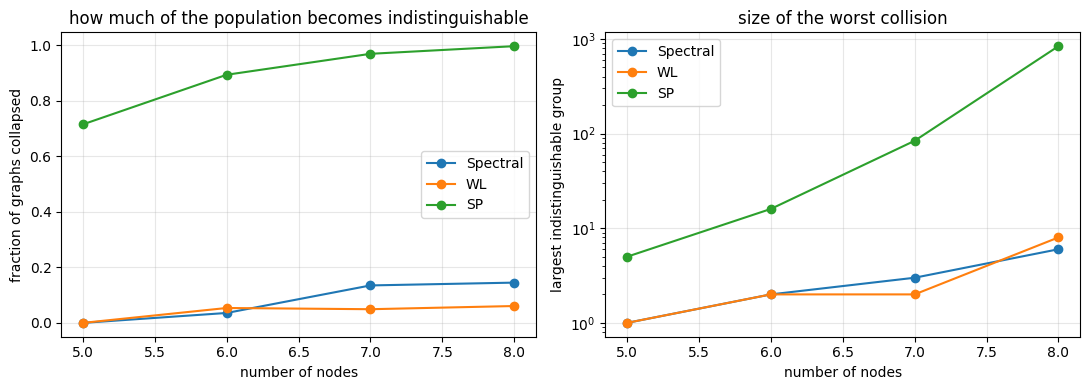

In [3]:

def charpoly_int(M):
    n = len(M); A = M.astype(np.int64); I = np.eye(n, dtype=np.int64)
    Mk, c = None, [1]
    for k in range(1, n + 1):
        Mk = I.copy() if k == 1 else A @ Mk + c[-1] * I
        q, r = divmod(-int(np.trace(A @ Mk)), k)
        if r:
            raise ArithmeticError("integer overflow in charpoly")
        c.append(q)
    return tuple(c)

def sp_profile(g):
    d = dict(nx.all_pairs_shortest_path_length(g))
    return tuple(sorted(np.bincount([d[u][v] for u in g for v in g if u < v]).tolist()))

def certificates(ns=(5, 6, 7, 8), wl_iters=3):
    out = []
    for n in ns:
        p = geng_all(n, connected=True)
        spec, wl, spl = defaultdict(int), defaultdict(int), defaultdict(int)
        for i, g in enumerate(p):
            L = np.array(nx.laplacian_matrix(g).todense(), dtype=np.int64)
            spec[charpoly_int(L)] += 1
            wl[nx.weisfeiler_lehman_graph_hash(g, iterations=wl_iters)] += 1
            spl[sp_profile(g)] += 1
            if i % 500 == 0:
                prog("D1", i + 1, len(p), f"n={n}")
        prog("D1", len(p), len(p), f"n={n}")
        for name, dd in [("Spectral", spec), ("WL", wl), ("SP", spl)]:
            sz = np.array([v for v in dd.values() if v > 1])
            cov = int(sz.sum())
            out.append(dict(n=n, dist=name, distinct_points=len(dd), collapsed=cov,
                            total=len(p), frac=round(cov / len(p), 4),
                            largest_group=int(sz.max()) if len(sz) else 1))
        out.append(dict(n=n, dist="GED", distinct_points=len(p), collapsed=0,
                        total=len(p), frac=0.0, largest_group=1))
    return pd.DataFrame(out)

D1 = certificates()
print("\nBlock 2 results : ")
print("distinct_points is :  how many different values the distance can produce")
print("collapsed       is :  graphs sharing their value with at least one other graph")
print("largest_group   is :  size of the biggest set of mutually indistinguishable graphs\n")
print(D1.to_string(index=False))
print("\nGED is zero only between isomorphic graphs, so it collapses nothing. it is the reference against which the tractable distances are measured.")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for dn in ["Spectral", "WL", "SP"]:
    s = D1[D1.dist == dn]
    ax[0].plot(s.n, s.frac, marker="o", label=dn)
    ax[1].plot(s.n, s.largest_group, marker="o", label=dn)
ax[0].set_xlabel("number of nodes"); ax[0].set_ylabel("fraction of graphs collapsed")
ax[0].set_title("how much of the population becomes indistinguishable")
ax[1].set_xlabel("number of nodes"); ax[1].set_ylabel("largest indistinguishable group")
ax[1].set_yscale("log"); ax[1].set_title("size of the worst collision")
for a in ax:
    a.grid(alpha=.3); a.legend()
fig.tight_layout(); plt.show()

# **Block 3 : What each distance is a function of**


**Block 2 says what a distance cannot see at all. Most pairs are not identical though, and this block asks what the non zero numbers are made of.We take a uniform sample from the full population of connected graphs. No classes, no labels, no property we are trying to separate, so there is nothing to be biased.Every pair gives one distance value and one absolute difference in each of seven simple descriptors. We regress the distance on those differences and read off:marginal variance : what a descriptor explains on its ownunique variance   : what it explains that no other descriptor could, computed by refitting without it and taking the dropR2_all            : what all seven explain togetherunexplained       : 1 - R2_all, the part of the distance that no standard graph invariant accounts for. this is the distance's own signature.The gap between marginal and unique is the confounding: if edge count explains 0.93alone but only 0.17 uniquely, most of its influence is shared with descriptors that are themselves driven by edge count.Because this uses no designed dataset, its conclusions can be used to predict what will happen on the designed datasets in Block 7 without inheriting their bias.**


  computed GED       n= 60  167.7s
D2      [######..................]     1/4     0s +    0s GED                               
  computed Spectral  n=200    0.2s
D2      [############............]     2/4    17s +   17s Spectral                          
  computed WL        n=200    0.0s
D2      [##################......]     3/4    39s +   13s WL                                
  computed SP        n=200    0.0s
D2      [########################]     4/4    62s +    0s SP                                

Block 3 results : 

unique variance : 
    dist  graphs  R2_all  unexplained  u_n_edges  u_max_deg  u_min_deg  u_n_tri  u_clust  u_diam  u_deg_var
     GED      60   0.418        0.582      0.059      0.000      0.003    0.001    0.004   0.000      0.063
Spectral     200   0.954        0.046      0.169      0.000      0.000    0.007    0.000   0.000      0.013
      WL     200   0.412        0.588      0.046      0.002      0.004    0.005    0.001   0.004      0.060
      SP     20

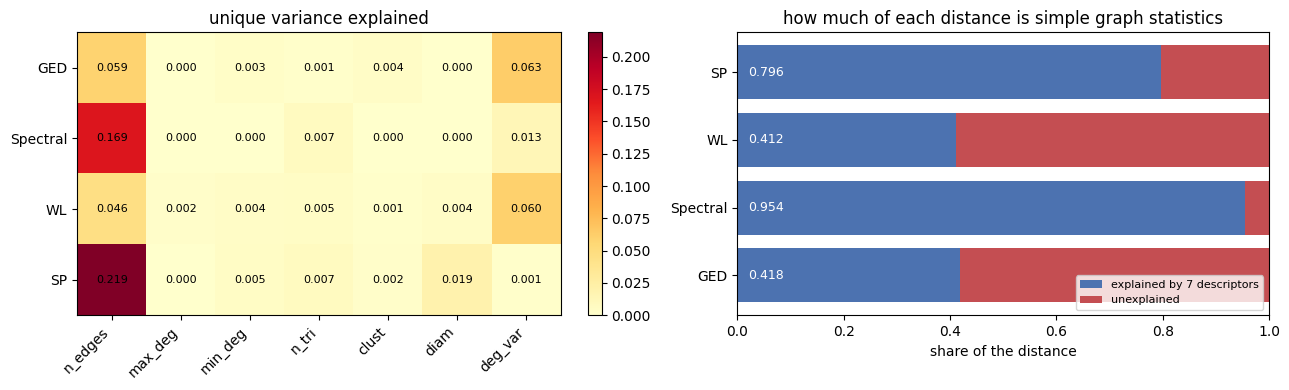

In [4]:
PROF_COVS = ["n_edges", "max_deg", "min_deg", "n_tri", "clust", "diam", "deg_var"]

def _r2(A, y):
    X = np.c_[A, np.ones(len(y))]
    b = lstsq(X, y, rcond=None)[0]
    r = y - X @ b
    return 1.0 - float(r @ r) / float(y @ y)

def sensitivity_profile(n=7, n_sample=200, ged_sample=60, n_boot=200, seed=0):
    rng = random.Random(seed)
    base = [_lab(nx.convert_node_labels_to_integers(g.copy()))
            for g in rng.sample(geng_all(n, connected=True), n_sample)]
    rows, ds = [], all_distances()
    for j, d in enumerate(ds):
        S = base[:ged_sample] if d.name == "GED" else base
        iu = np.triu_indices(len(S), 1)
        X = np.column_stack([np.abs(np.subtract.outer(cov_values(S, c), cov_values(S, c)))[iu]
                             for c in PROF_COVS])
        X = (X - X.mean(0)) / (X.std(0) + 1e-12)
        D = cached_D(S, d)
        y = D[iu]; y = (y - y.mean()) / (y.std() + 1e-12)
        full = _r2(X, y)
        r = {"dist": d.name, "graphs": len(S), "pairs": len(y),
             "R2_all": round(full, 3), "unexplained": round(1 - full, 3)}
        bs_rng = np.random.default_rng(seed)
        for k, c in enumerate(PROF_COVS):
            u = full - _r2(np.delete(X, k, 1), y)
            bs = [(_r2(X[s], y[s]) - _r2(np.delete(X, k, 1)[s], y[s]))
                  for s in (bs_rng.choice(len(y), len(y), True) for _ in range(n_boot))]
            r["u_" + c] = round(u, 3)
            r["ci_" + c] = round(1.96 * float(np.std(bs)), 3)
            r["m_" + c] = round(_r2(X[:, [k]], y), 3)
        rows.append(r)
        prog("D2", j + 1, len(ds), d.name)
    return pd.DataFrame(rows)

D2 = sensitivity_profile()
print("\nBlock 3 results : ")
print("\nunique variance : ")
print(D2[["dist", "graphs", "R2_all", "unexplained"] +
         ["u_" + c for c in PROF_COVS]].to_string(index=False))
print("\nmarginal variance : ")
print(D2[["dist"] + ["m_" + c for c in PROF_COVS]].to_string(index=False))
print("\n95% CI : ")
print(D2[["dist"] + ["ci_" + c for c in PROF_COVS]].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
U = D2.set_index("dist")[["u_" + c for c in PROF_COVS]]
U.columns = PROF_COVS
im = ax[0].imshow(U.values, cmap="YlOrRd", aspect="auto", vmin=0)
ax[0].set_xticks(range(len(PROF_COVS))); ax[0].set_xticklabels(PROF_COVS, rotation=45, ha="right")
ax[0].set_yticks(range(len(U))); ax[0].set_yticklabels(U.index)
for i in range(U.shape[0]):
    for j in range(U.shape[1]):
        ax[0].text(j, i, f"{U.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
ax[0].set_title("unique variance explained")
fig.colorbar(im, ax=ax[0], fraction=.04)
ax[1].barh(D2.dist, D2.R2_all, color="#4c72b0", label="explained by 7 descriptors")
ax[1].barh(D2.dist, D2.unexplained, left=D2.R2_all, color="#c44e52", label="unexplained")
for i, r in D2.iterrows():
    ax[1].text(0.02, i, f"{r.R2_all:.3f}", va="center", fontsize=9, color="white")
ax[1].set_xlim(0, 1); ax[1].set_xlabel("share of the distance")
ax[1].set_title("how much of each distance is simple graph statistics")
ax[1].legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

# **Block 4 : Response to a single controlled edit**


**Block 3 measures how a distance co-varies with descriptors across a population, but in a population everything moves together: graphs with more edges also have more triangles and higher degrees. A small unique variance could mean the distance is blind, or just that the descriptor never varies independently enough to isolate. This block removes the ambiguity by switching from correlation to response. Take one graph, change one property by exactly one unit, change nothing else, and ask whether the distance moves.The mechanism is a rewire: remove one existing edge, add one absent edge. Node count and edge count are identical by construction, and since Block 3 shows edge count is the dominant confound for every distance, removing it by construction rather than by matching is exactly what is needed. For each source graph we build two rewires: one that moves the target property by one, one that leaves it unchanged. Both cost the same to perform. If a distance cannot tell them apart it is blind to that property in the strictest sense available.**

D3      [########################]    16/16    28s +    0s min_deg SP                        

Block 4 results : 
effect size, paired on the source graph, edge count identical in both rewires

dist       GED     SP  Spectral     WL
target                                
diam     0.000  1.572     0.542  0.166
max_deg  0.000  0.345     0.312  1.131
min_deg  0.320  0.547     0.693  0.582
n_tri    0.224  0.289    -0.018 -0.072
 target     dist  pairs  d_changed  d_unchanged  effect   ci_lo  ci_hi  sees
   diam      GED     40     2.0000       2.0000   0.000  0.0000 0.0000 BLIND
   diam Spectral     40     1.1676       0.9455   0.542  0.0705 0.3545   yes
   diam       WL     40     0.6611       0.6460   0.166 -0.0153 0.0414 BLIND
   diam       SP     40     0.1320       0.0412   1.572  0.0675 0.1156   yes
max_deg      GED     40     2.0000       2.0000   0.000  0.0000 0.0000 BLIND
max_deg Spectral     40     0.9840       0.8552   0.312 -0.0644 0.3212 BLIND
max_deg       WL     40     0.6954

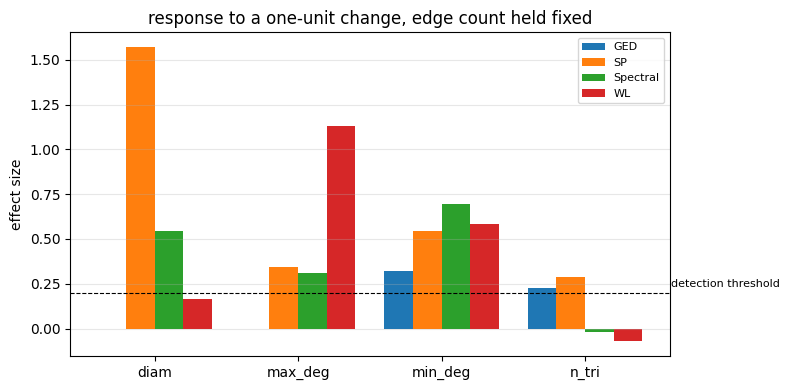

In [5]:
def rewire(g, rng, tries=60):
    for _ in range(tries):
        h = g.copy()
        e = list(h.edges())
        ne = [(u, v) for u in h for v in h if u < v and not h.has_edge(u, v)]
        if not e or not ne:
            return None
        h.remove_edge(*rng.choice(e)); h.add_edge(*rng.choice(ne))
        if nx.is_connected(h):
            return h
    return None

def contrast_pairs(g, target, rng, tries=400):
    base = COVS[target](g); hit = null = None
    for _ in range(tries):
        h = rewire(g, rng)
        if h is None:
            continue
        d = COVS[target](h) - base
        if hit is None and abs(d) == 1:
            hit = h
        elif null is None and d == 0:
            null = h
        if hit is not None and null is not None:
            return hit, null
    return None, None

def minimal_contrast(n=8, n_graphs=40, targets=("diam", "max_deg", "n_tri", "min_deg"), seed=0):
    rng = random.Random(seed)
    p = geng_all(n, min_edges=10, max_edges=14, connected=True)
    ds = all_distances(); rows = []
    done, tot = 0, len(targets) * len(ds)
    for target in targets:
        trip = []
        while len(trip) < n_graphs:
            g = _lab(nx.convert_node_labels_to_integers(rng.choice(p).copy()))
            hit, null = contrast_pairs(g, target, rng)
            if hit is not None:
                trip.append((g, _lab(hit), _lab(null)))
        for d in ds:
            dt = np.array([d.distance_matrix([a, b])[0, 1] for a, b, _ in trip])
            dn = np.array([d.distance_matrix([a, c])[0, 1] for a, _, c in trip])
            diff = dt - dn
            pooled = np.sqrt(.5 * (dt.var(ddof=1) + dn.var(ddof=1))) + 1e-12
            bs = [np.mean(rng.choices(list(diff), k=len(diff))) for _ in range(500)]
            rows.append(dict(target=target, dist=d.name, pairs=len(trip),
                             d_changed=round(float(dt.mean()), 4),
                             d_unchanged=round(float(dn.mean()), 4),
                             effect=round(float(diff.mean() / pooled), 3),
                             ci_lo=round(float(np.quantile(bs, .025)), 4),
                             ci_hi=round(float(np.quantile(bs, .975)), 4)))
            done += 1; prog("D3", done, tot, f"{target} {d.name}")
    df = pd.DataFrame(rows)
    # a distance sees the property if it responds and the interval excludes zero
    df["sees"] = np.where((df.ci_lo > 0) & (df.effect > 0.2), "yes", "BLIND")
    return df

D3 = minimal_contrast()
print("\nBlock 4 results : ")
print("effect size, paired on the source graph, edge count identical in both rewires\n")
print(D3.pivot_table(index="target", columns="dist", values="effect").round(3).to_string())
print(D3.to_string(index=False))
print("\nd_changed and d_unchanged are the mean distances to the two rewires. where they are equal the distance cannot tell a consequential edit from a cosmetic one.")

fig, ax = plt.subplots(figsize=(8, 4))
piv = D3.pivot_table(index="target", columns="dist", values="effect")
w, x = 0.2, np.arange(len(piv))
for i, dn in enumerate(piv.columns):
    ax.bar(x + i * w - 1.5 * w, piv[dn], w, label=dn)
ax.axhline(0.2, ls="--", c="k", lw=.8)
ax.text(len(piv) - 0.4, 0.23, "detection threshold", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylabel("effect size"); ax.set_title("response to a one-unit change, edge count held fixed")
ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

# **Block 5 : Class separation and the relationship between geometry and recovery**


**Blocks 2 to 4 describe the distances. Blocks 6 to 10 measure what algorithms achieve on labelled datasets. This block sits between them and answers the question that makes the later results readable: before any algorithm runs, how far apart do the classes actually land?Without this, a low score has three possible causes that cannot be told apart: the distance is blind, the dataset barely separates, or the algorithm failed. Measuring the middle one turns every later result into a deviation from an expectation.For each dataset and distance we compute separation (cohen_d, separation AUC and its permutation null, min_gap), shape (collinear, n_dims, var_top2, neg_mass), and one reference SOM clustering so the geometry can be calibrated against an outcome. The calibration table at the end is what every later block is read against.**

G1      [########################]   143/143    75s +    0s colorability/R3 SP                

Block 5 results : 

per dataset and distance, averaged over seeds
     dataset round     dist     auc    null  cohen_d  min_gap  collinear  n_dims  var_top2  neg_mass      ari
colorability    R1      GED 0.58400 0.52100  0.33200  0.21500     0.5000   33.00   0.21000     0.278  0.06500
colorability    R1       SP 0.60550 0.52125  0.24950  0.19350     0.5000    3.00   0.99525     0.000  0.16375
colorability    R1 Spectral 0.80250 0.52275  1.17950  1.02900     1.0000    7.00   0.66975     0.000  0.51575
colorability    R1       WL 0.56075 0.51725  0.18400  0.38650     0.8750   59.00   0.21100     0.000  0.00400
colorability    R2      GED 0.99300 0.55100  3.58800  2.81200     1.0000   10.00   0.81600     0.107  1.00000
colorability    R2       SP 0.83900 0.54625  1.55225  0.86675     0.5000    6.00   0.97225     0.000  0.48450
colorability    R2 Spectral 0.89100 0.53750  1.55250  0.92200     1.

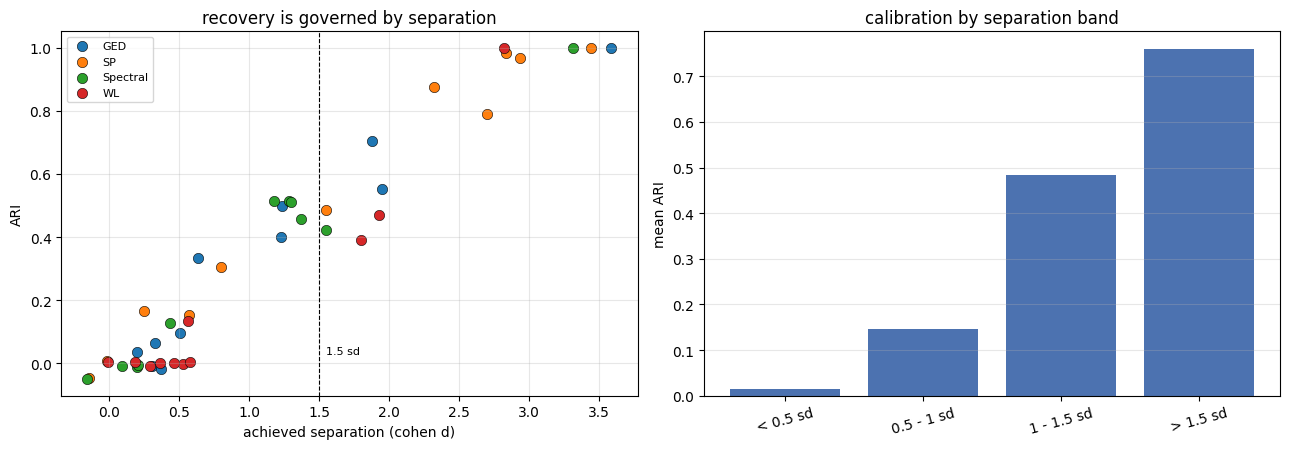

In [6]:
def run_G1(datasets):
    rows = []
    jobs = [(a, d) for a in datasets for d in dists_for(a[2])]
    for i, ((name, rd, s, g, y), d) in enumerate(jobs):
        D = cached_D(g, d)
        gm = geometry(D, y)
        auc = separation_auc(D, y)
        _, p95 = perm_null_auc(D, y, 300, s)
        som = MedianSOM((3, 3), 40, seed=0); som.fit(D)
        ari = adjusted_rand_score(y, merge_prototypes_to_k(D, som.prototypes_,
                                                          len(np.unique(y))))
        rows.append(dict(dataset=name, round=rd, seed=s, dist=d.name,
                         auc=round(auc, 3), null=round(p95, 3), ari=round(ari, 3),
                         **{k: round(v, 3) for k, v in gm.items()}))
        prog("G1", i + 1, len(jobs), f"{name}/{rd} {d.name}")
    return pd.DataFrame(rows)

G1 = run_G1(DATASETS)
cell = G1.groupby(["dataset", "round", "dist"]).mean(numeric_only=True).reset_index()

print("\nBlock 5 results : ")
print("\nper dataset and distance, averaged over seeds")
print(cell[["dataset", "round", "dist", "auc", "null", "cohen_d", "min_gap",
            "collinear", "n_dims", "var_top2", "neg_mass", "ari"]].to_string(index=False))

cell["band"] = pd.cut(cell.cohen_d, [-9, .5, 1, 1.5, 99],
                      labels=["< 0.5 sd", "0.5 - 1 sd", "1 - 1.5 sd", "> 1.5 sd"])
print("\nrecovery as a function of achieved separation")
print(cell.groupby("band", observed=True).ari.agg(["mean", "std", "count"]).round(3).to_string())

print("\nwhich geometry statistic predicts recovery")
for c in ["cohen_d", "auc", "min_gap", "var_top2"]:
    print(f"  spearman({c:9s}, ari) = {spearmanr(cell[c], cell.ari)[0]:+.3f}")

print("\ngeometry of each distance, averaged over datasets")
print(cell.groupby("dist")[["collinear", "var_top2", "neg_mass", "n_dims"]].mean().round(3).to_string())
print("\ncollinear near 1 means the classes lie in order along one axis, so they are three bins of a continuum rather than three separate clouds.")
print(" neg_mass above 0 means the distance is not Euclidean and no flat plot of it can be faithful.")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for dn in cell.dist.unique():
    s = cell[cell.dist == dn]
    ax[0].scatter(s.cohen_d, s.ari, s=55, edgecolors="k", linewidths=.4, label=dn)
b = cell.groupby("band", observed=True).ari.mean()
ax[0].axvline(1.5, ls="--", c="k", lw=.8)
ax[0].text(1.55, 0.03, "1.5 sd", fontsize=8)
ax[0].set_xlabel("achieved separation (cohen d)"); ax[0].set_ylabel("ARI")
ax[0].set_title("recovery is governed by separation")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].bar(range(len(b)), b.values, color="#4c72b0")
ax[1].set_xticks(range(len(b))); ax[1].set_xticklabels(b.index, rotation=15)
ax[1].set_ylabel("mean ARI"); ax[1].set_title("calibration by separation band")
ax[1].grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

# **Block 6 : Algorithm comparison on datasets of controlled difficulty**


**Comparing clustering algorithms across datasets of unknown difficulty tells younothing: a distance carrying no signal makes every algorithm look bad, and a hugelyseparated dataset makes every algorithm look good. This block puts difficulty on thex-axis so that what remains is the algorithm.We build planted partitions, the graph analogue of the Gaussian blobs used tocalibrate clustering methods in vector spaces. Pick three seed graphs; each class isfifteen graphs obtained by applying r random connectivity-preserving edits to itsseed. Two knobs set the difficulty: how far apart the seeds are, and how large r is.Choosing "distant" seeds requires a notion of distance, and fixing one would rig theexperiment in its favour. So the seed rule is a swept parameter: uniform random, andmaximin under Spectral, under SP, and under a consensus of all three. Reporting allfour makes the dependency visible rather than hidden.Difficulty is measured after the fact, not assumed. A distance that happens to placethe seeds far apart simply occupies the easy end of the curve.**

A1      [########################]    48/48    10s +    0s SP r=8                            

Block 6 results : 

separation achieved by each seed rule, in within class SD
dist                SP  Spectral    WL
rule      radius                      
SP        1       1.61      1.90  0.95
          2       1.01      1.21  0.74
          4       0.42      0.34  0.28
          8       0.21      0.20  0.10
Spectral  1       1.11      2.85  1.42
          2       0.72      1.86  1.22
          4       0.48      1.04  0.63
          8       0.19      0.32  0.26
consensus 1       1.61      2.46  1.29
          2       0.88      1.45  0.89
          4       0.41      0.68  0.47
          8       0.12      0.25  0.22
random    1       0.76      1.13  0.76
          2       0.52      0.60  0.38
          4       0.13      0.21  0.18
          8       0.03      0.05  0.04

ARI by difficulty and algorithm
algo         SOM  hier-avg  hier-comp  k-medoids
band                                       

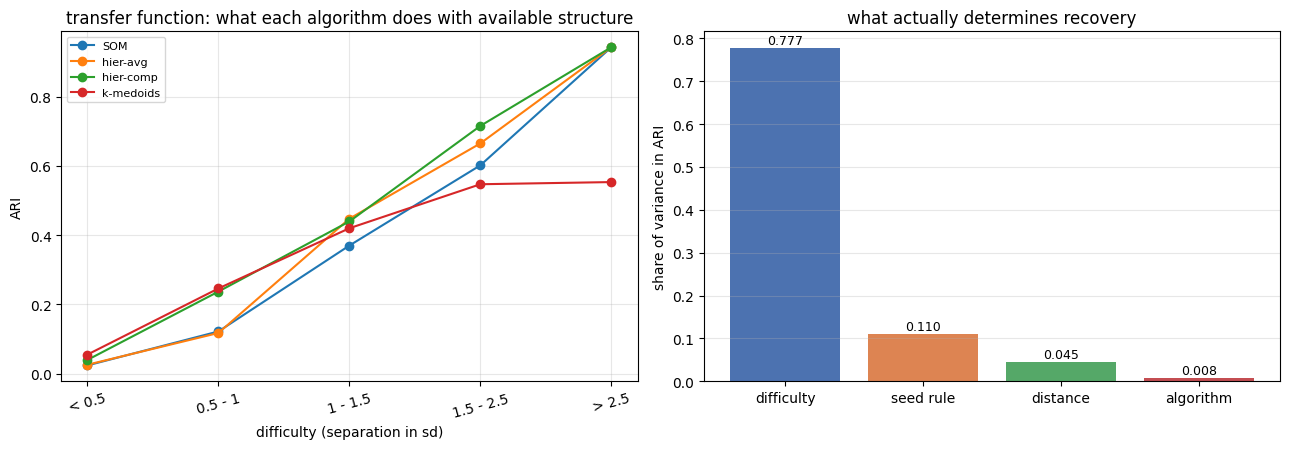

In [7]:
RULES = ["random", "consensus", "Spectral", "SP"]
RADII = [1, 2, 4, 8]
A1_DISTS = [SpectralDistance(), WLDistance(h=3), SPDistance()]

def perturb(g, r, rng):
    h = g.copy(); nodes = list(h.nodes())
    for _ in range(r):
        u, v = rng.sample(nodes, 2)
        if h.has_edge(u, v):
            h.remove_edge(u, v)
            if not nx.is_connected(h): h.add_edge(u, v)
        else:
            h.add_edge(u, v)
    return _lab(h)

def pick_seeds(p, K, rule, rng, dists, n_cand=60):
    if rule == "random":
        return rng.sample(p, K)
    cand = rng.sample(p, min(n_cand, len(p)))
    Ms = {}
    for d in dists:
        M = _clean_D(d.distance_matrix(cand)); Ms[d.name] = M / (M.max() + 1e-12)
    M = np.mean(list(Ms.values()), 0) if rule == "consensus" else Ms[rule]
    idx = [int(np.unravel_index(M.argmax(), M.shape)[0])]
    while len(idx) < K:
        idx.append(int(np.argmax(M[:, idx].min(1))))
    return [cand[i] for i in idx]

def run_A1(n=9, K=3, per_class=15, seeds=3, grid=(3, 3)):
    p = geng_all(n, min_edges=10, max_edges=14, connected=True)
    rows = []
    jobs = [(r, rad, s) for r in RULES for rad in RADII for s in range(seeds)]
    for i, (rule, rad, s) in enumerate(jobs):
        rng = random.Random(s)
        sds = pick_seeds(p, K, rule, rng, A1_DISTS)
        g, y = [], []
        for c, s0 in enumerate(sds):
            for _ in range(per_class):
                g.append(perturb(nx.convert_node_labels_to_integers(s0.copy()), rad, rng))
                y.append(c)
        y = np.asarray(y)
        for d in A1_DISTS:
            D = _clean_D(d.distance_matrix(g))
            sep = geometry(D, y)["cohen_d"]
            preds = {}
            for a in range(3):
                som = MedianSOM(grid, 40, seed=a); som.fit(D)
                preds.setdefault("SOM", []).append(
                    merge_prototypes_to_k(D, som.prototypes_, K))
                preds.setdefault("k-medoids", []).append(kmedoids(D, K, seed=a))
            for lk, nm in [("average", "hier-avg"), ("complete", "hier-comp")]:
                preds[nm] = [AgglomerativeClustering(n_clusters=K, metric="precomputed",
                                                     linkage=lk).fit_predict(D)]
            for algo, ps in preds.items():
                rows.append(dict(rule=rule, radius=rad, seed=s, dist=d.name, algo=algo,
                                 sep=sep,
                                 ari=float(np.mean([adjusted_rand_score(y, q) for q in ps]))))
        prog("A1", i + 1, len(jobs), f"{rule} r={rad}")
    return pd.DataFrame(rows)

A1 = run_A1()
A1["band"] = pd.cut(A1.sep, [-9, .5, 1, 1.5, 2.5, 99],
                    labels=["< 0.5", "0.5 - 1", "1 - 1.5", "1.5 - 2.5", "> 2.5"])

print("\nBlock 6 results : ")
print("\nseparation achieved by each seed rule, in within class SD")
print(A1.pivot_table(index=["rule", "radius"], columns="dist", values="sep",
                     aggfunc="mean").round(2).to_string())

print("\nARI by difficulty and algorithm")
print(A1.pivot_table(index="band", columns="algo", values="ari",
                     aggfunc="mean", observed=True).round(3).to_string())

print("\nvariance in recovery attributable to each factor")
for f, nm in [("band", "difficulty"), ("rule", "seed rule"),
              ("dist", "distance"), ("algo", "algorithm")]:
    print(f"  eta2({nm:11s}) = {eta2(A1.ari, A1[f].astype(str)):.4f}")

print("\npooled mean ARI by algorithm")
print(A1.groupby("algo").ari.agg(["mean", "std"]).round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
piv = A1.pivot_table(index="band", columns="algo", values="ari", aggfunc="mean", observed=True)
for algo in piv.columns:
    ax[0].plot(range(len(piv)), piv[algo], marker="o", label=algo)
ax[0].set_xticks(range(len(piv))); ax[0].set_xticklabels(piv.index, rotation=15)
ax[0].set_xlabel("difficulty (separation in sd)"); ax[0].set_ylabel("ARI")
ax[0].set_title("transfer function: what each algorithm does with available structure")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
fac = ["band", "rule", "dist", "algo"]
lab = ["difficulty", "seed rule", "distance", "algorithm"]
vals = [eta2(A1.ari, A1[f].astype(str)) for f in fac]
ax[1].bar(lab, vals, color=["#4c72b0", "#dd8452", "#55a868", "#c44e52"])
for i, v in enumerate(vals):
    ax[1].text(i, v + .01, f"{v:.3f}", ha="center", fontsize=9)
ax[1].set_ylabel("share of variance in ARI")
ax[1].set_title("what actually determines recovery")
ax[1].grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()

# **Block 7 : Confound ladder and prediction test on the designed datasets**


**The designed datasets are biased by construction: choosing graphs by a propertymakes the classes differ in that property and in everything correlated with it. Thatbias cannot be removed by building a cleverer dataset, so we handle it differently.The datasets are used only to test predictions written down beforehand, from Blocks3 and 4, which used no designed data at all. A dataset used for falsification cannotbe accused of being built to demonstrate the thing it falsifies.predict_cell reads only D3 and the list of covariates matched in each round. Writingit as a function rather than by hand means it cannot be adjusted after seeing theresults, and it can be printed in full for the reader to check.The verdict for each cell is mechanical:below the permutation null : blindabove the best single covariate : succeedsin between : confoundedThe middle case matters: separating the classes is not evidence of anything if onesimple number does it better.**

A2      [########################]   143/143    81s +    0s colorability/R3 SP                

Block 7 results : 

predictions, generated before this block was run
edit-wide     R1  GED         confounded
                  Spectral    confounded
                  WL          confounded
                  SP          confounded
conn-wide     R1  GED         confounded
                  Spectral    confounded
                  WL          confounded
                  SP          confounded
              R2  GED              blind
                  Spectral      succeeds
                  WL          confounded
                  SP          confounded
              R3  GED              blind
                  Spectral      succeeds
                  WL          confounded
                  SP          confounded
geom-wide     R1  GED         confounded
                  Spectral    confounded
                  WL          confounded
                  SP          confounded
              R

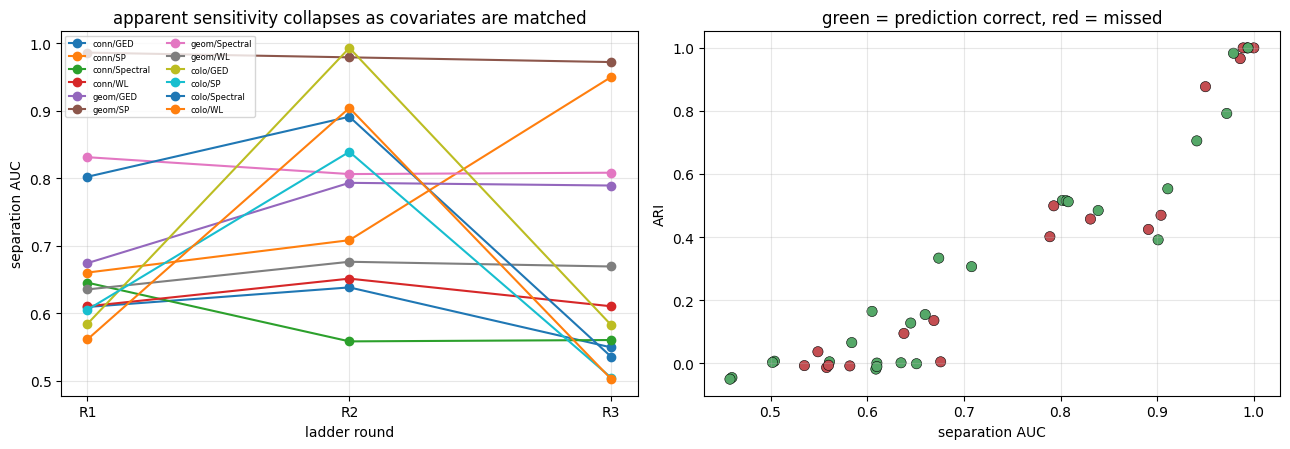

In [8]:
PROBE = {"n_edges": None, "diam": "diam", "n_comp": "min_deg", "n_B": None, None: "n_tri"}
READS_LABELS = {"GED", "WL"}
MATCHED = {("edit-wide", "R1"): [],
           ("conn-wide", "R1"): [], ("conn-wide", "R2"): ["n_edges"],
           ("conn-wide", "R3"): ["n_edges", "max_deg", "min_deg"],
           ("geom-wide", "R1"): [], ("geom-wide", "R2"): ["n_edges"],
           ("geom-wide", "R3"): ["n_edges", "min_deg"],
           ("pure-label", "R1"): [],
           ("colorability", "R1"): [], ("colorability", "R2"): [],
           ("colorability", "R3"): ["n_edges"]}

def predict_cell(dataset, rd, dist):
    target = TARGET[dataset]
    matched = MATCHED[(dataset, rd)]
    if target == "n_B":
        return "succeeds" if dist in READS_LABELS else "blind"
    if target == "n_edges":
        return "confounded"
    if target is None:
        return "blind" if "n_edges" in matched else "confounded"
    probe = PROBE[target]
    row = D3[(D3.target == probe) & (D3.dist == dist)]
    sees = len(row) and row.sees.iloc[0] == "yes"
    if not matched:
        return "confounded"
    if not sees:
        return "blind"
    eff = D3[D3.target == probe].set_index("dist").effect
    return "succeeds" if eff[dist] == eff.max() else "confounded"

PREDICTIONS = {(ds, rd, d): predict_cell(ds, rd, d)
               for (ds, rd) in MATCHED for d in ["GED", "Spectral", "WL", "SP"]}

def verdict(auc, null, cov):
    return "blind" if auc <= null else ("succeeds" if auc > cov else "confounded")

def run_A2(datasets):
    rows = []
    jobs = [(a, d) for a in datasets for d in dists_for(a[2])]
    for i, ((name, rd, s, g, y), d) in enumerate(jobs):
        cb, cby = cov_baseline(g, y, exclude=(TARGET[name],) if TARGET[name] else ())
        D = cached_D(g, d)
        auc = separation_auc(D, y); _, p95 = perm_null_auc(D, y, 300, s)
        som = MedianSOM((3, 3), 40, seed=0); som.fit(D)
        ari = adjusted_rand_score(y, merge_prototypes_to_k(D, som.prototypes_,
                                                          len(np.unique(y))))
        rows.append(dict(dataset=name, round=rd, dist=d.name, seed=s,
                         auc=round(auc, 3), null=round(p95, 3), cov=round(cb, 3),
                         cov_by=cby, ari=round(ari, 3),
                         predicted=PREDICTIONS.get((name, rd, d.name), "-"),
                         observed=verdict(auc, p95, cb)))
        prog("A2", i + 1, len(jobs), f"{name}/{rd} {d.name}")
    return pd.DataFrame(rows)

A2 = run_A2(DATASETS)
g2 = A2.groupby(["dataset", "round", "dist"]).agg(
    auc=("auc", "mean"), null=("null", "mean"), cov=("cov", "mean"),
    cov_by=("cov_by", lambda s: s.mode()[0]), ari=("ari", "mean"),
    predicted=("predicted", "first"),
    observed=("observed", lambda s: s.mode()[0])).round(3).reset_index()
g2["hit"] = g2.predicted == g2.observed

print("\nBlock 7 results : ")
print("\npredictions, generated before this block was run")
print(pd.Series(PREDICTIONS).rename("predicted").to_string())
print("auc = separation achieved, null = what shuffled labels give,")
print("cov = best single covariate, cov_by = which one\n")
print(g2.to_string(index=False))
print(f"\nprediction hit rate {g2.hit.mean():.0%}  ({g2.hit.sum()}/{len(g2)} cells)")
print("\npredicted rows against observed columns")
print(pd.crosstab(g2.predicted, g2.observed).to_string())
cat = (((g2.predicted == "blind") & (g2.observed == "succeeds")).sum() +
       ((g2.predicted == "succeeds") & (g2.observed == "blind")).sum())
print(f"\ninversions (predicted blind but succeeded, or the reverse): {cat}")
print("\nmisses")
print(g2[~g2.hit][["dataset", "round", "dist", "auc", "null", "cov",
                   "predicted", "observed", "ari"]].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for ds in ["conn-wide", "geom-wide", "colorability"]:
    s = g2[g2.dataset == ds]
    for dn in s.dist.unique():
        q = s[s.dist == dn].sort_values("round")
        if len(q) > 1:
            ax[0].plot(q["round"], q.auc, marker="o", label=f"{ds[:4]}/{dn}")
ax[0].set_ylabel("separation AUC"); ax[0].set_xlabel("ladder round")
ax[0].set_title("apparent sensitivity collapses as covariates are matched")
ax[0].legend(fontsize=6, ncol=2); ax[0].grid(alpha=.3)
ax[1].scatter(g2.auc, g2.ari, c=["#c44e52" if not h else "#55a868" for h in g2.hit],
              s=55, edgecolors="k", linewidths=.4)
ax[1].set_xlabel("separation AUC"); ax[1].set_ylabel("ARI")
ax[1].set_title("green = prediction correct, red = missed")
ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

# **Block 8 : Clustering without labels**


**Every block so far has had an answer key. That is not how clustering is used: in practice there are no labels, and the question is whether any grouping exists at all. This block runs the pipeline the way it would actually be used, and asks two questions that need no ground truth.is the result repeatable? run with five different random starts and measure ho much the partitions agree with each other; then repeaton 80% subsamples. real structure survives both, noise does not. this is the only notion of validity available without labels.what is it a grouping of? for each discovered cluster, check which covariate the partition explains best. that names the semantics the distance imposed.Part one uses 120 graphs drawn uniformly from the whole population: no classes, no design, nothing to be biased. Part two uses the designed datasets with the labels, revealed afterwards only as a diagnostic named ari_check, never a verdict.**

A3-P    [###.....................]     1/8     0s +    0s n=7 GED                           
  computed Spectral  n=120    0.1s
A3-P    [######..................]     2/8     0s +    1s n=7 Spectral                      
  computed WL        n=120    0.0s
A3-P    [#########...............]     3/8     1s +    1s n=7 WL                            
  computed SP        n=120    0.0s
A3-P    [###############.........]     5/8     4s +    3s GED skipped at n=8                
  computed Spectral  n=120    0.1s
A3-P    [##################......]     6/8     5s +    2s n=8 Spectral                      
  computed WL        n=120    0.0s
A3-P    [#####################...]     7/8     6s +    1s n=8 WL                            
  computed SP        n=120    0.0s
A3-P    [########################]     8/8     7s +    0s n=8 SP                            

Block 8 results:

Part one: undesigned population
       population  graphs     dist   sil  k_found  util  stab_seed  stab_sub  tracks   e

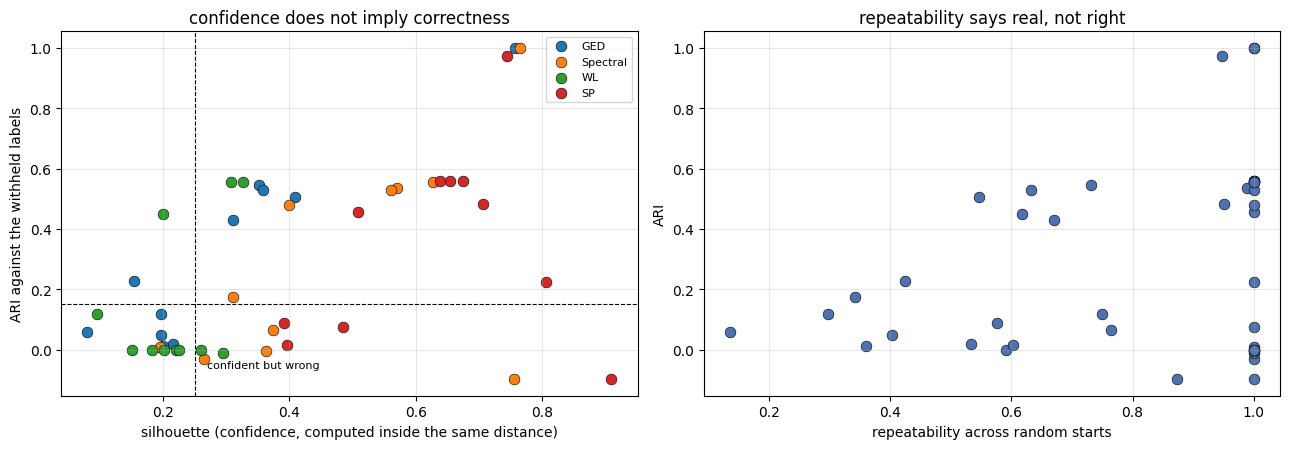

In [9]:
SIL_REAL, UTIL_GUARD, A3_SEEDS, N_SUB = 0.25, 0.30, 5, 6

def explore(D, graphs, y=None, seed=0, grid=(3, 3)):
    n = len(graphs); preds, sils, ks, uts = [], [], [], []
    for a in range(A3_SEEDS):
        som = MedianSOM(grid, 40, seed=a); som.fit(D)
        r = merge_to_best_silhouette(D, som.prototypes_)
        preds.append(r["pred"]); sils.append(r["sil"]); ks.append(r["n_clusters"])
        uts.append(len(np.unique(som.labels_)) / len(som.prototypes_))
    stab = float(np.mean([adjusted_rand_score(preds[i], preds[j])
                          for i in range(len(preds)) for j in range(i + 1, len(preds))]))
    rng = np.random.default_rng(seed); subs = []
    for _ in range(N_SUB):
        idx = np.sort(rng.choice(n, int(.8 * n), replace=False))
        s = MedianSOM(grid, 40, seed=0); s.fit(D[np.ix_(idx, idx)])
        ps = merge_to_best_silhouette(D[np.ix_(idx, idx)], s.prototypes_)["pred"]
        subs.append(adjusted_rand_score(preds[0][idx], ps))
    tr = tracks_what(preds[0], graphs)
    sil, ut = nanmean_safe(sils), float(np.mean(uts))
    ari = float(np.mean([adjusted_rand_score(y, p) for p in preds])) if y is not None else np.nan
    if ut < UTIL_GUARD:
        v = "collapsed map"
    elif np.isnan(sil):
        v = "no usable structure"
    elif sil > SIL_REAL and (y is None or ari < .15):
        v = "structure found" if y is None else "real structure, NOT the labels"
    elif sil > SIL_REAL and ari >= .5:
        v = "structure matches the labels"
    elif sil > SIL_REAL:
        v = "partly aligned"
    else:
        v = "weak structure"
    return dict(sil=round(sil, 3), k_found=round(float(np.mean(ks)), 2), util=round(ut, 3),
                stab_seed=round(stab, 3), stab_sub=round(float(np.mean(subs)), 3),
                ari_check=round(ari, 3) if y is not None else np.nan,
                tracks=tr[0][1], eta=round(tr[0][0], 3),
                second=tr[1][1], eta_second=round(tr[1][0], 3), verdict=v), preds[0]

rows, profs = [], []
jobs = [(n, d) for n in (7, 8) for d in dists_for(0)]
for i, (n, d) in enumerate(jobs):
    rng = random.Random(0)
    S = [_lab(nx.convert_node_labels_to_integers(g.copy()))
         for g in rng.sample(geng_all(n, connected=True), 120)]
    if d.name == "GED":
        S = S[:60] if n == 7 else None
    if S is None:
        prog("A3-P", i + 1, len(jobs), "GED skipped at n=8"); continue
    D = cached_D(S, d)
    r, pred = explore(D, S)
    rows.append(dict(population=f"all connected n={n}", graphs=len(S), dist=d.name, **r))
    for cl in np.unique(pred):
        m = pred == cl
        profs.append(dict(population=f"n={n}", dist=d.name, cluster=int(cl), size=int(m.sum()),
                          **{c: round(float(cov_values(S, c)[m].mean()), 2)
                             for c in ["n_edges", "diam", "max_deg", "n_tri"]}))
    prog("A3-P", i + 1, len(jobs), f"n={n} {d.name}")
A3P = pd.DataFrame(rows)

print("\nBlock 8 results:")
print("\nPart one: undesigned population")
print(A3P[["population", "graphs", "dist", "sil", "k_found", "util", "stab_seed",
           "stab_sub", "tracks", "eta", "second", "eta_second"]].to_string(index=False))
print("\nstab_seed below about 0.5 means the clustering changes substantially between what the discovered groups contain runs, so whatever it found is not reproducible.")
print("\n")
print(pd.DataFrame(profs).to_string(index=False))

rows2 = []
jobs = [(a, d) for a in DATASETS if a[2] == 0 for d in dists_for(a[2])]
for i, ((name, rd, s, g, y), d) in enumerate(jobs):
    r, _ = explore(cached_D(g, d), g, y, seed=s)
    rows2.append(dict(dataset=name, round=rd, dist=d.name, **r))
    prog("A3-R", i + 1, len(jobs), f"{name}/{rd} {d.name}")
A3 = pd.DataFrame(rows2)
print("\nBlock 8 results:")
print("\nPart two: designed datasets with labels withheld")
print(A3.to_string(index=False))
print("\nari_check is revealed only afterwards and is a diagnostic. the verdicts here are stability and characterisation, both computable without any labels.")
print("\n")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for dn in A3.dist.unique():
    s = A3[A3.dist == dn]
    ax[0].scatter(s.sil, s.ari_check, s=60, edgecolors="k", linewidths=.4, label=dn)
ax[0].axhline(0.15, ls="--", c="k", lw=.8); ax[0].axvline(SIL_REAL, ls="--", c="k", lw=.8)
ax[0].text(SIL_REAL + .02, -0.06, "confident but wrong", fontsize=8)
ax[0].set_xlabel("silhouette (confidence, computed inside the same distance)")
ax[0].set_ylabel("ARI against the withheld labels")
ax[0].set_title("confidence does not imply correctness")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[1].scatter(A3.stab_seed, A3.ari_check, s=60, c="#4c72b0", edgecolors="k", linewidths=.4)
ax[1].set_xlabel("repeatability across random starts"); ax[1].set_ylabel("ARI")
ax[1].set_title("repeatability says real, not right")
ax[1].grid(alpha=.3)
fig.tight_layout(); plt.show()

# **Block 9 : Anatomy of the SOM map, and the choice of grid size**


**Block 6 shows the SOM scores about the same as the other algorithms, which raises the question of why to use it. The answer is that it produces a map: a grid where each neuron has a fixed position and neighbouring neurons should hold similar graphs. This block therefore stops treating the SOM as a competitor and instead studies the structure of the map itself.Each neuron is assigned the majority class of the graphs it contains, forming territories across the grid. Two measures describe these territories: pieces counts how many disconnected fragments a class occupies, while concentration measures how much of the class lies within its largest fragment. If the map preserves topology, each recovered class should appear as a single contiguous patch.Topographic error is defined as the fraction of graphs whose best and second-best matching neurons are not neighbours on the grid. This is reported against a shuffled-grid null model, since the raw value alone has no meaning without a reference scale. Quantization error measures the mean distance from each graph to its assigned neuron and reflects pure compression. Prototype entropy evaluates how evenly neurons are distributed across the true classes.Finally, the choice of grid size is examined by comparing three standard selection rules against simply fixing K: a knee point in quantization error, the maximum silhouette score, and a knee point in the silhouette curve.**

A5      [########################]  2112/2112    60s +    0s colorability/R3 SP 1x16           

Block 9 results : 

map territories: does a recovered class occupy one contiguous region?
           pieces   conc     te  te_ratio  util    ari
recovered                                             
False       2.219  0.493  0.534     0.713  0.98  0.032
True        1.797  0.780  0.439     0.586  1.00  0.661
pieces near 1 means yes. te_ratio near 0 means the layout is far better than a randomly shuffled grid; a value of 1 would mean no better than chance.

what the map adds, correlation with recovery
  spearman(conc          , ari) = +0.765
  spearman(proto_entropy , ari) = -0.039
  spearman(pieces        , ari) = -0.181
  spearman(sil_merge     , ari) = +0.428
  spearman(te            , ari) = -0.244
  spearman(qe            , ari) = +0.027

Grid size: what you ask for against what the map delivers
    k_eff  n_active   util     qe  sil_merge  k_found    ari   conc
K                       

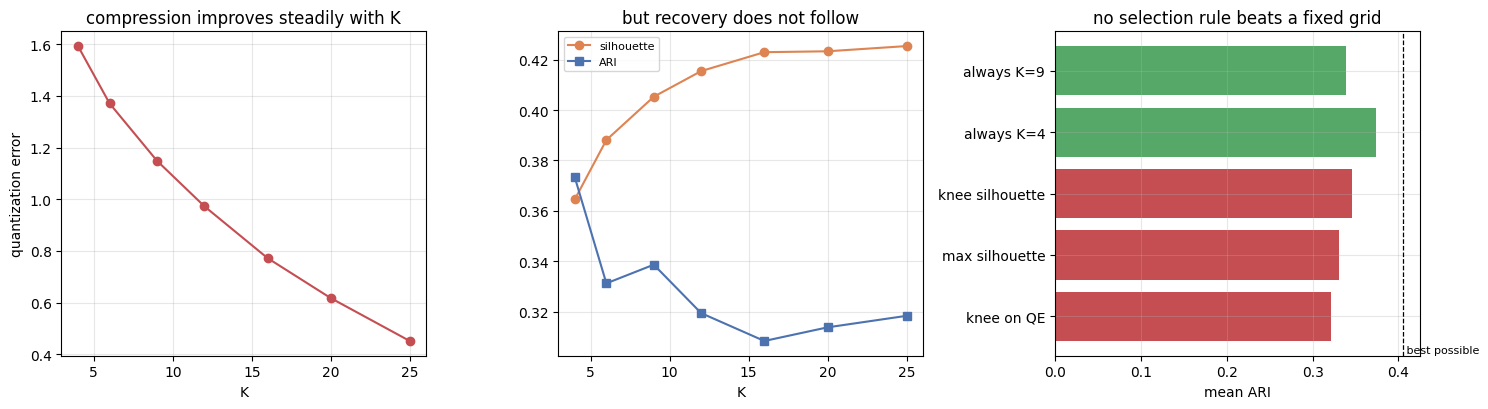

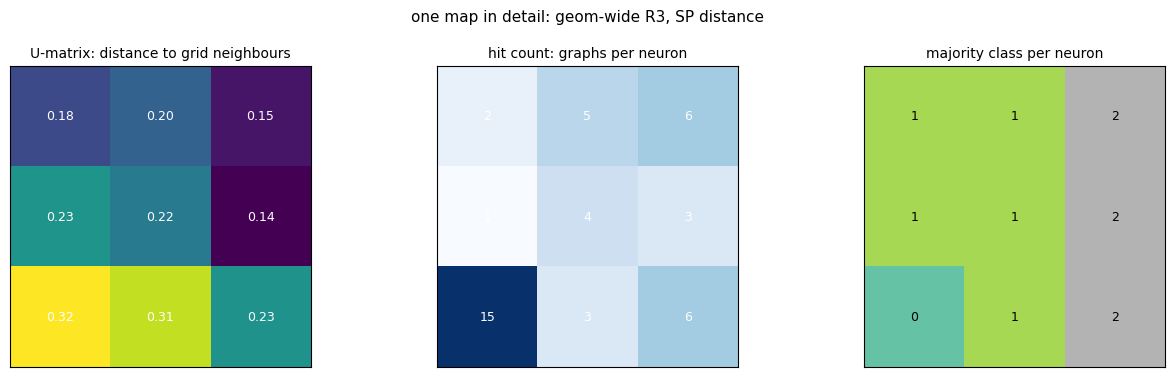


light regions in the U-matrix are boundaries between dissimilar neurons.
the majority-class panel shows each class occupying a connected region.


In [10]:
KS = [4, 6, 9, 12, 16, 20, 25]
SHAPES = {9: [(3, 3), (1, 9)], 12: [(3, 4), (2, 6), (1, 12)], 16: [(4, 4), (2, 8), (1, 16)]}
A5_SEEDS = 4

def shape_for(K):
    r = int(np.sqrt(K))
    return (r, K // r) if r * (K // r) == K else (1, K)

def run_A5(datasets):
    jobs = []
    for (name, rd, s, g, y) in datasets:
        if s != 0:
            continue
        for d in dists_for(s):
            b = [(K, shape_for(K)) for K in KS if K < len(g)]
            b += [(K, sh) for K, ss in SHAPES.items() for sh in ss
                  if sh != shape_for(K) and K < len(g)]
            jobs.append((name, rd, g, y, d, b))
    rows, done = [], 0
    total = sum(len(b) * A5_SEEDS for *_, b in jobs)
    for (name, rd, g, y, d, b) in jobs:
        D = cached_D(g, d); kt = len(np.unique(y))
        for (K, shape) in b:
            for sd in range(A5_SEEDS):
                som = MedianSOM(shape, 40, seed=sd)
                fine = som.fit(D); pr = som.prototypes_; act = np.unique(fine)
                r = merge_to_best_silhouette(D, pr)
                q = map_quality(D, y, som, kt)
                te = topographic_error(D, pr, som.coords_used_)
                rows.append(dict(
                    dataset=name, round=rd, dist=d.name, K=K,
                    shape=f"{shape[0]}x{shape[1]}", canonical=(shape == shape_for(K)),
                    seed=sd, qe=quantization_error(D, pr), te=te,
                    te_ratio=te / (te_null(D, pr, som.coords_used_, sd) + 1e-12),
                    sil_merge=r["sil"], k_found=r["n_clusters"],
                    ari=q["ari_merged"], ari_fine=q["ari_fine"],
                    pieces=q["pieces"], conc=q["concentration"],
                    util=len(act) / K, n_active=len(act), k_eff=len(np.unique(pr)),
                    proto_entropy=proto_entropy(pr, y, kt)))
                done += 1
                prog("A5", done, total, f"{name}/{rd} {d.name} {shape[0]}x{shape[1]}")
    return pd.DataFrame(rows)

A5 = run_A5(DATASETS)
C = A5[A5.canonical]
A5 = A5.assign(recovered=A5.ari > .3)

print("\nBlock 9 results : ")
print("\nmap territories: does a recovered class occupy one contiguous region?")
print(A5.groupby("recovered")[["pieces", "conc", "te", "te_ratio", "util", "ari"]]
      .mean().round(3).to_string())
print("pieces near 1 means yes. te_ratio near 0 means the layout is far better than a randomly shuffled grid; a value of 1 would mean no better than chance.")
print("\nwhat the map adds, correlation with recovery")
for c in ["conc", "proto_entropy", "pieces", "sil_merge", "te", "qe"]:
    s = A5[[c, "ari"]].dropna()
    print(f"  spearman({c:14s}, ari) = {spearmanr(s[c], s.ari)[0]:+.3f}")

print("\nGrid size: what you ask for against what the map delivers")
print(C.groupby("K")[["k_eff", "n_active", "util", "qe", "sil_merge", "k_found",
                      "ari", "conc"]].mean().round(3).to_string())

cur = C.groupby(["dataset", "round", "dist", "K"])[["qe", "sil_merge", "ari"]].mean().reset_index()
mq = ms = tot = 0; sel = []
for k, gg in cur.groupby(["dataset", "round", "dist"]):
    gg = gg.sort_values("K")
    if len(gg) < 5:
        continue
    tot += 1
    mq += bool(np.all(np.diff(gg.qe.values) <= 1e-9))
    sv = gg.sil_merge.values
    ms += bool(not np.any(np.isnan(sv)) and np.all(np.diff(sv) >= -1e-9))
    if np.all(np.isnan(sv)):
        continue
    at = lambda K: float(gg[gg.K == K].ari.iloc[0])
    r = dict(K_qe_knee=int(gg.K.iloc[_knee_index(gg.K.values, gg.qe.values)]),
             K_sil_max=int(gg.K.iloc[int(np.nanargmax(sv))]),
             K_sil_knee=int(gg.K.iloc[_knee_index(gg.K.values, -np.nan_to_num(sv, nan=np.nanmin(sv)))]),
             K_best=int(gg.K.iloc[int(np.argmax(gg.ari.values))]),
             ari_best=gg.ari.max(), ari_K4=at(4), ari_K9=at(9))
    for nm in ("K_qe_knee", "K_sil_max", "K_sil_knee"):
        r["ari_" + nm] = at(r[nm])
    sel.append(r)
S = pd.DataFrame(sel)

print(f"\nquantization error decreases monotonically in K in {mq}/{tot} cells")
print(f"silhouette increases monotonically in K in {ms}/{tot} cells")
print(f"silhouette range across the whole K sweep: "
      f"{C.groupby('K').sil_merge.mean().max() - C.groupby('K').sil_merge.mean().min():.3f}")

print("\nGrid selection rules against fixed choices")
print(f"  {'rule':24s} {'picks the best K':>17s} {'mean ARI':>10s}")
for nm, kc in [("knee on quantization", "K_qe_knee"), ("maximum of silhouette", "K_sil_max"),
               ("knee on silhouette", "K_sil_knee")]:
    print(f"  {nm:24s} {(S[kc] == S.K_best).mean():16.0%} {S['ari_' + kc].mean():10.3f}")
for K in (4, 9):
    print(f"  {'always use K=' + str(K):24s} {(S.K_best == K).mean():16.0%} "
          f"{S['ari_K' + str(K)].mean():10.3f}")
print(f"  {'best possible choice':24s} {'100%':>16s} {S.ari_best.mean():10.3f}")
print(f"\nthe two rules agree with each other in {(S.K_qe_knee == S.K_sil_max).mean():.0%} of cells")
print("K actually best:", S.K_best.value_counts().sort_index().to_dict())
print(f"\nvariance in ARI explained by grid size = {eta2(cur.ari, cur.K):.4f}")
print(f"variance explained by which dataset and distance it is = "
      f"{eta2(cur.ari, cur.dataset + cur['round'] + cur.dist):.4f}")

print("\nGrid shape at fixed K, neighbourhood width scaled to the grid")
for K in sorted(SHAPES):
    s2 = A5[A5.K == K]
    if s2["shape"].nunique() > 1:
        print(f"  K={K}")
        print(s2.groupby("shape")[["ari", "conc", "te_ratio", "util"]].mean().round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
kk = C.groupby("K")[["qe", "sil_merge", "ari"]].mean()
ax[0].plot(kk.index, kk.qe, marker="o", color="#c44e52")
ax[0].set_xlabel("K"); ax[0].set_ylabel("quantization error")
ax[0].set_title("compression improves steadily with K")
ax[1].plot(kk.index, kk.sil_merge, marker="o", color="#dd8452", label="silhouette")
ax[1].plot(kk.index, kk.ari, marker="s", color="#4c72b0", label="ARI")
ax[1].set_xlabel("K"); ax[1].set_title("but recovery does not follow")
ax[1].legend(fontsize=8)
names = ["knee on QE", "max silhouette", "knee silhouette", "always K=4", "always K=9"]
vals = [S.ari_K_qe_knee.mean(), S.ari_K_sil_max.mean(), S.ari_K_sil_knee.mean(),
        S.ari_K4.mean(), S.ari_K9.mean()]
ax[2].barh(names, vals, color=["#c44e52"] * 3 + ["#55a868"] * 2)
ax[2].axvline(S.ari_best.mean(), ls="--", c="k", lw=.9)
ax[2].text(S.ari_best.mean(), -0.6, " best possible", fontsize=8)
ax[2].set_xlabel("mean ARI"); ax[2].set_title("no selection rule beats a fixed grid")
for a in ax:
    a.grid(alpha=.3)
fig.tight_layout(); plt.show()

# a worked example of one map: U-matrix, hit counts, and class territories
_name, _rd, _s, _g, _y = [a for a in DATASETS if a[0] == "geom-wide" and a[1] == "R3"][0]
_D = cached_D(_g, SPDistance())
_som = MedianSOM((3, 3), 40, seed=0); _fine = _som.fit(_D)
_U = umatrix(_D, _som.prototypes_, _som.coords_used_, 3, 3)
_hits = np.array([(_fine == j).sum() for j in range(9)]).reshape(3, 3)
_maj = np.full(9, -1)
for j in range(9):
    m = np.where(_fine == j)[0]
    if len(m):
        _maj[j] = Counter(_y[m]).most_common(1)[0][0]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
for a, M, t, cm in [(ax[0], _U, "U-matrix: distance to grid neighbours", "viridis"),
                    (ax[1], _hits, "hit count: graphs per neuron", "Blues"),
                    (ax[2], _maj.reshape(3, 3), "majority class per neuron", "Set2")]:
    im = a.imshow(M, cmap=cm); a.set_title(t, fontsize=10)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            a.text(j, i, f"{M[i, j]:.2f}" if M.dtype.kind == "f" else f"{M[i, j]}",
                   ha="center", va="center", fontsize=9,
                   color="w" if cm != "Set2" else "k")
    a.set_xticks([]); a.set_yticks([])
fig.suptitle(f"one map in detail: {_name} {_rd}, SP distance", fontsize=11)
fig.tight_layout(); plt.show()
print("\nlight regions in the U-matrix are boundaries between dissimilar neurons.")
print("the majority-class panel shows each class occupying a connected region.")

# **Block 10 : Case study : can any distance see the chromatic number?**


**The four datasets in Block 1 test properties we chose, partly because they were easy to control. Chromatic number is different: it is a property mathematicians care about, it is difficult to compute, and none of these distances was designed with it in mind. The earlier blocks build and validate the instrument; this block applies it to a genuine scientific question.The three rounds each close one possible alternative explanation. R1 fixes the number of nodes and edges so that graph size cannot explain the result, but a graph requiring four colours often contains a large clique, leaving clique size as a possible factor. R2 uses the Mycielskian construction, which increases the chromatic number while keeping graphs triangle-free, removing cliques as an explanation. However, this construction roughly doubles the graph size each time, causing the resulting classes to differ substantially in size. R3 fixes n = 8 and matches the edge count exactly, comparing graphs with chi = 2 against graphs with chi = 3.eta_chi measures how much of the chromatic number is explained by the discovered partition, while tracks identifies the covariate that the clustering organized itself around instead.**

O       [########################]    39/39   740s +    0s R3 SP                             

Block 10 results : 
round     dist  graphs  classes   auc  null   cov    sep    ari  eta_chi  cov_by  tracks    verdict
   R1      GED    60.0      3.0 0.584 0.521 0.926  0.332  0.065    0.080   n_tri min_deg confounded
   R1       SP    60.0      3.0 0.605 0.521 0.925  0.250  0.164    0.186   n_tri   clust confounded
   R1 Spectral    60.0      3.0 0.802 0.523 0.925  1.180  0.516    0.728   n_tri   clust confounded
   R1       WL    60.0      3.0 0.561 0.517 0.925  0.184  0.004    0.062   n_tri min_deg confounded
   R2      GED    33.0      3.0 0.993 0.551 0.849  3.588  1.000    1.000 max_deg max_deg   specific
   R2       SP    33.0      3.0 0.839 0.546 0.847  1.552  0.484    0.619 max_deg max_deg confounded
   R2 Spectral    33.0      3.0 0.891 0.538 0.847  1.552  0.424    0.750 max_deg max_deg   specific
   R2       WL    33.0      3.0 0.904 0.541 0.847  1.926  0.469    0.750 max_deg max_

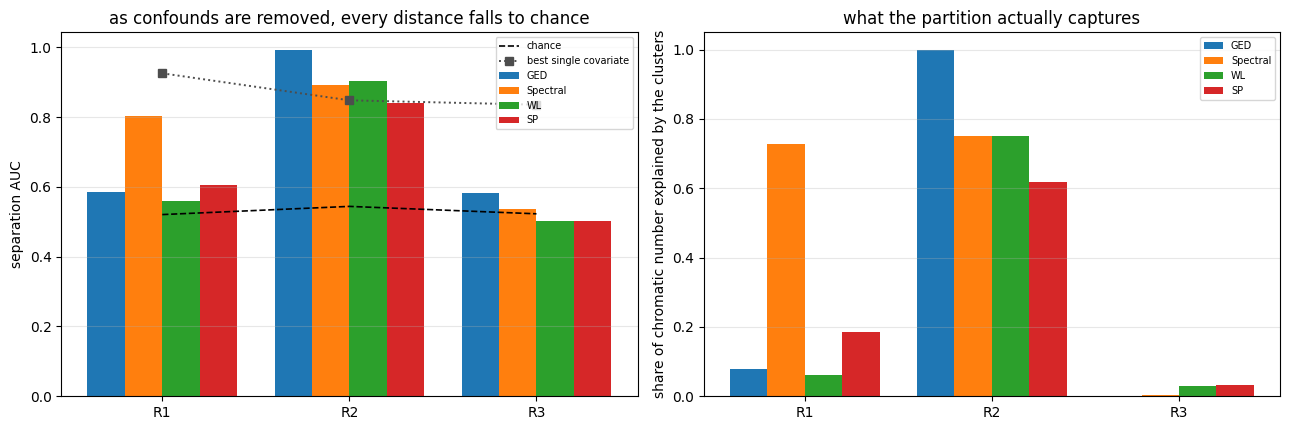

In [11]:
COL = [(n, r, s, g, y) for (n, r, s, g, y) in DATASETS if n == "colorability"]

def run_O(datasets):
    rows = []
    jobs = [(a, d) for a in datasets for d in dists_for(a[2])]
    for i, ((name, rd, s, g, y), d) in enumerate(jobs):
        cb, cby = cov_baseline(g, y)
        D = cached_D(g, d)
        auc = separation_auc(D, y); _, p95 = perm_null_auc(D, y, 300, s)
        gm = geometry(D, y); kt = len(np.unique(y))
        som = MedianSOM((3, 3), 40, seed=0); som.fit(D)
        pred = merge_prototypes_to_k(D, som.prototypes_, kt)
        chi = np.array([chromatic_number(x) for x in g], float)
        tr = tracks_what(pred, g)
        rows.append(dict(round=rd, dist=d.name, graphs=len(g), classes=kt,
                         auc=round(auc, 3), null=round(p95, 3), cov=round(cb, 3),
                         cov_by=cby, sep=round(gm["cohen_d"], 3),
                         ari=round(adjusted_rand_score(y, pred), 3),
                         eta_chi=round(eta2(chi, pred), 3), tracks=tr[0][1]))
        prog("O", i + 1, len(jobs), f"{rd} {d.name}")
    return pd.DataFrame(rows)

O = run_O(COL)
g3 = O.groupby(["round", "dist"]).mean(numeric_only=True).reset_index()
g3["cov_by"] = O.groupby(["round", "dist"]).cov_by.agg(lambda s: s.mode()[0]).values
g3["tracks"] = O.groupby(["round", "dist"]).tracks.agg(lambda s: s.mode()[0]).values
g3["verdict"] = np.where(g3.auc <= g3.null, "BLIND",
                np.where(g3.auc > g3["cov"], "specific", "confounded"))

print("\nBlock 10 results : ")
print(g3.round(3).to_string(index=False))

print("\nCollapse from round 1 to round 3")
for dn in ["GED", "Spectral", "WL", "SP"]:
    s = g3[g3.dist == dn].set_index("round")
    if {"R1", "R3"} <= set(s.index):
        print(f"  {dn:9s} R1 {s.loc['R1','auc']:.3f} -> R3 {s.loc['R3','auc']:.3f}"
              f"   change {s.loc['R3','auc'] - s.loc['R1','auc']:+.3f}")

r3 = g3[g3["round"] == "R3"]
print("\nthe decisive comparison, round 3")
print(f"  best distance          : {r3.auc.max():.3f} ({r3.loc[r3.auc.idxmax(),'dist']})")
print(f"  what shuffled labels give : {r3.null.mean():.3f}")
print(f"  best single covariate  : {r3["cov"].mean():.3f} ({r3.cov_by.mode()[0]})")
print("\na single scalar decodes the property that every graph distance misses, so the information is present in the graph and simply not weighted by the distances, what the clusters organised themselves by instead.")
print(g3[["round", "dist", "eta_chi", "tracks", "ari"]].to_string(index=False))

print("\nThis was predicted by Block 4: chromatic number lives in odd cycles, and no distance responds to a single triangle at fixed edge count.")
print("\n")
print(D3[D3.target == "n_tri"][["dist", "effect", "ci_lo", "ci_hi", "sees"]].to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
rds = ["R1", "R2", "R3"]
w, x = 0.2, np.arange(len(rds))
for i, dn in enumerate(["GED", "Spectral", "WL", "SP"]):
    s = g3[g3.dist == dn].set_index("round").reindex(rds)
    ax[0].bar(x + i * w - 1.5 * w, s.auc.values, w, label=dn)
ax[0].plot(x, g3.groupby("round").null.mean().reindex(rds).values, "k--", lw=1.2, label="chance")
ax[0].plot(x, g3.groupby("round")["cov"].mean().reindex(rds).values, color="0.3",
           marker="s", ls=":", lw=1.4, label="best single covariate")
ax[0].set_xticks(x); ax[0].set_xticklabels(rds); ax[0].set_ylabel("separation AUC")
ax[0].set_title("as confounds are removed, every distance falls to chance")
ax[0].legend(fontsize=7); ax[0].grid(alpha=.3, axis="y")
for i, dn in enumerate(["GED", "Spectral", "WL", "SP"]):
    s = g3[g3.dist == dn].set_index("round").reindex(rds)
    ax[1].bar(x + i * w - 1.5 * w, s.eta_chi.values, w, label=dn)
ax[1].set_xticks(x); ax[1].set_xticklabels(rds)
ax[1].set_ylabel("share of chromatic number explained by the clusters")
ax[1].set_title("what the partition actually captures")
ax[1].legend(fontsize=7); ax[1].grid(alpha=.3, axis="y")
fig.tight_layout(); plt.show()